# DATA IMPORT & VERIFICATION

In [34]:
# BLOCK 1 — DATA IMPORT & VERIFICATION
# Datasets: 1 real-participants (RP) + 24 synthetic (GPT/DeepSeek/Llama, Steps 1–8)
# ============================================================================

# Standard library
from pathlib import Path
import random
import warnings

# Data
import numpy as np
import pandas as pd

# Machine learning
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Statistics
import statsmodels.api as sm

# Visualization
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import FancyBboxPatch
from matplotlib.lines import Line2D
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial"]

warnings.filterwarnings('ignore')

random.seed(42)
np.random.seed(42)

# ── Paths ─────────────────────────────────────────────────────────────────────
NOTEBOOK_DIR = Path().resolve()
CLEAN_DIR    = NOTEBOOK_DIR / "clean"

# ── Load real participants dataset ────────────────────────────────────────────
rp = pd.read_csv(CLEAN_DIR / "rp.csv")

# ── Load synthetic datasets ───────────────────────────────────────────────────
gpt_step1       = pd.read_csv(CLEAN_DIR / "gpt_step1.csv")
deepseek_step1  = pd.read_csv(CLEAN_DIR / "deepseek_step1.csv")
llama_step1     = pd.read_csv(CLEAN_DIR / "llama_step1.csv")

gpt_step2       = pd.read_csv(CLEAN_DIR / "gpt_step2.csv")
deepseek_step2  = pd.read_csv(CLEAN_DIR / "deepseek_step2.csv")
llama_step2     = pd.read_csv(CLEAN_DIR / "llama_step2.csv")

gpt_step3       = pd.read_csv(CLEAN_DIR / "gpt_step3.csv")
deepseek_step3  = pd.read_csv(CLEAN_DIR / "deepseek_step3.csv")
llama_step3     = pd.read_csv(CLEAN_DIR / "llama_step3.csv")

gpt_step4       = pd.read_csv(CLEAN_DIR / "gpt_step4.csv")
deepseek_step4  = pd.read_csv(CLEAN_DIR / "deepseek_step4.csv")
llama_step4     = pd.read_csv(CLEAN_DIR / "llama_step4.csv")

gpt_step5       = pd.read_csv(CLEAN_DIR / "gpt_step5.csv")
deepseek_step5  = pd.read_csv(CLEAN_DIR / "deepseek_step5.csv")
llama_step5     = pd.read_csv(CLEAN_DIR / "llama_step5.csv")

gpt_step6       = pd.read_csv(CLEAN_DIR / "gpt_step6.csv")
deepseek_step6  = pd.read_csv(CLEAN_DIR / "deepseek_step6.csv")
llama_step6     = pd.read_csv(CLEAN_DIR / "llama_step6.csv")

gpt_step7       = pd.read_csv(CLEAN_DIR / "gpt_step7.csv")
deepseek_step7  = pd.read_csv(CLEAN_DIR / "deepseek_step7.csv")
llama_step7     = pd.read_csv(CLEAN_DIR / "llama_step7.csv")

gpt_step8       = pd.read_csv(CLEAN_DIR / "gpt_step8.csv")
deepseek_step8  = pd.read_csv(CLEAN_DIR / "deepseek_step8.csv")
llama_step8     = pd.read_csv(CLEAN_DIR / "llama_step8.csv")

# ── Dataset registry ──────────────────────────────────────────────────────────
ALL_DATASETS = {
    "rp":              rp,
    "gpt_step1":       gpt_step1,  "deepseek_step1": deepseek_step1, "llama_step1": llama_step1,
    "gpt_step2":       gpt_step2,  "deepseek_step2": deepseek_step2, "llama_step2": llama_step2,
    "gpt_step3":       gpt_step3,  "deepseek_step3": deepseek_step3, "llama_step3": llama_step3,
    "gpt_step4":       gpt_step4,  "deepseek_step4": deepseek_step4, "llama_step4": llama_step4,
    "gpt_step5":       gpt_step5,  "deepseek_step5": deepseek_step5, "llama_step5": llama_step5,
    "gpt_step6":       gpt_step6,  "deepseek_step6": deepseek_step6, "llama_step6": llama_step6,
    "gpt_step7":       gpt_step7,  "deepseek_step7": deepseek_step7, "llama_step7": llama_step7,
    "gpt_step8":       gpt_step8,  "deepseek_step8": deepseek_step8, "llama_step8": llama_step8,
}

# ============================================================================
# FEATURE ENGINEERING — BPI mean scores
# ============================================================================
BPI_INTERF_COLS = ["bpi_1", "bpi_2", "bpi_3", "bpi_4", "bpi_5", "bpi_6", "bpi_7"]
BPI_INT_COLS    = ["bpi_8", "bpi_9", "bpi_10", "bpi_11"]
BPI_ALL_COLS    = BPI_INTERF_COLS + BPI_INT_COLS

for name, df in ALL_DATASETS.items():
    df["bpi_interf_mean"] = df[BPI_INTERF_COLS].mean(axis=1, skipna=False)
    df["bpi_int_mean"]    = df[BPI_INT_COLS].mean(axis=1, skipna=False)
    df["bpi_mean"]        = df[BPI_ALL_COLS].mean(axis=1, skipna=False)

# ============================================================================
# OUTPUT 1 — Shape summary (rows × columns per dataset)
# ============================================================================
print("=" * 55)
print("OUTPUT 1 — Dataset shapes")
print("=" * 55)
print(f"{'Dataset':<20} {'Rows':>6} {'Cols':>6}")
print("-" * 55)
for name, df in ALL_DATASETS.items():
    print(f"  {name:<18} {df.shape[0]:>6} {df.shape[1]:>6}")

# ============================================================================
# OUTPUT 2 — Column consistency across synthetic datasets
#            All synthetic datasets must share the same columns as rp
# ============================================================================
print("\n" + "=" * 55)
print("OUTPUT 2 — Column consistency vs. RP")
print("=" * 55)

rp_cols = set(rp.columns)
all_consistent = True

for name, df in ALL_DATASETS.items():
    if name == "rp":
        continue
    extra   = set(df.columns) - rp_cols
    missing = rp_cols - set(df.columns)
    if extra or missing:
        all_consistent = False
        if missing: print(f"  ✗ {name:<18} MISSING: {sorted(missing)}")
        if extra:   print(f"  ✗ {name:<18} EXTRA:   {sorted(extra)}")
    else:
        print(f"  ✓ {name:<18} columns match RP ({df.shape[1]} cols)")

if all_consistent:
    print(f"\n  ✓ All synthetic datasets share the same {len(rp_cols)} columns as RP")

# ============================================================================
# OUTPUT 3 — Key variable completeness (no unexpected NaNs)
# ============================================================================
KEY_COLS = [
    "edad", "genero", "causa_dolor",
    "bpi_interf_sum", "bpi_int_sum", "bpi_sum",
    "bpi_interf_mean", "bpi_int_mean", "bpi_mean",
    "dass_total_interp", "mirswb_total"
]

print("\n" + "=" * 55)
print("OUTPUT 3 — Key variable completeness (% non-null)")
print("=" * 55)
print(f"{'Dataset':<20}", end="")
for col in KEY_COLS:
    print(f"  {col[:13]:>13}", end="")
print()
print("-" * 75)

for name, df in ALL_DATASETS.items():
    print(f"  {name:<18}", end="")
    for col in KEY_COLS:
        if col in df.columns:
            pct = df[col].notna().mean() * 100
            flag = "✓" if pct == 100 else f"{pct:.0f}%"
        else:
            flag = "N/A"
        print(f"  {flag:>13}", end="")
    print()

print("\n✓ Import complete — datasets ready for analysis.")

OUTPUT 1 — Dataset shapes
Dataset                Rows   Cols
-------------------------------------------------------
  rp                    235     80
  gpt_step1             235     80
  deepseek_step1        235     80
  llama_step1           235     80
  gpt_step2             235     80
  deepseek_step2        235     80
  llama_step2           235     80
  gpt_step3             235     80
  deepseek_step3        235     80
  llama_step3           235     80
  gpt_step4             235     80
  deepseek_step4        235     80
  llama_step4           235     80
  gpt_step5             235     80
  deepseek_step5        235     80
  llama_step5           235     80
  gpt_step6             235     80
  deepseek_step6        235     80
  llama_step6           235     80
  gpt_step7             235     80
  deepseek_step7        235     80
  llama_step7           235     80
  gpt_step8             235     80
  deepseek_step8        235     80
  llama_step8           235     80

OUTPUT 

# REAL POPULATION (RP) ANALYSIS

## RP Sociodemographic and clinical characteristics

### Table 1

In [35]:
# TABLE 1 — Sociodemographic and clinical characteristics
# ============================================================
import pandas as pd
import numpy as np

# ── Age ──────────────────────────────────────────────────────
age_mean = rp["edad"].mean()
age_sd   = rp["edad"].std()
age_min  = rp["edad"].min()
age_max  = rp["edad"].max()
print(f"Age: mean={age_mean:.1f}, SD={age_sd:.1f}, range={age_min:.0f}–{age_max:.0f}")

# ── Gender ────────────────────────────────────────────────────
gender_counts = rp["genero"].value_counts()
n_female = gender_counts.get("Femenino", 0)
pct_female = round(n_female / len(rp) * 100, 1)
print(f"\nGender — Female: n={n_female} ({pct_female:.1f}%)")
print(gender_counts)

# ── Education ─────────────────────────────────────────────────
edu_counts = rp["estudios"].value_counts()
edu_pct    = rp["estudios"].value_counts(normalize=True) * 100
print("\nEducation:")
for cat in edu_counts.index:
    print(f"  {cat}: {edu_counts[cat]} ({edu_pct[cat]:.1f}%)")

# ── Marital status ────────────────────────────────────────────
civil_counts = rp["estado_civil"].value_counts()
civil_pct    = rp["estado_civil"].value_counts(normalize=True) * 100
print("\nMarital status:")
for cat in civil_counts.index:
    print(f"  {cat}: {civil_counts[cat]} ({civil_pct[cat]:.1f}%)")

# ── Country of birth ──────────────────────────────────────────
print("\nCountry of birth:")
n_esp      = (rp["nacimiento_pais"] == "España").sum()    
n_col      = (rp["nacimiento_pais"] == "Colombia").sum()  
n_fra      = (rp["nacimiento_pais"] == "Francia").sum()   
n_otros    = len(rp) - n_esp - n_col - n_fra            
pct_otros  = n_otros / len(rp) * 100

print(f"España:          {n_esp}  ({n_esp/len(rp)*100:.1f}%)")
print(f"Colombia:        {n_col}   ({n_col/len(rp)*100:.1f}%)")
print(f"Francia:         {n_fra}   ({n_fra/len(rp)*100:.1f}%)")
print(f"Other countries: {n_otros}  ({pct_otros:.1f}%)")

# ── Pain duration ─────────────────────────────────────────────
# Check which column name is used
pain_col = "duracion_dolor" if "duracion_dolor" in rp.columns else "dolor_duracion"
pain_median = rp[pain_col].median()
pain_q1     = rp[pain_col].quantile(0.25)
pain_q3     = rp[pain_col].quantile(0.75)
pain_mean   = rp[pain_col].mean()
pain_sd     = rp[pain_col].std()
print(f"\nPain duration: mean={pain_mean:.1f}, SD={pain_sd:.1f}")
print(f"Pain duration: median={pain_median:.1f}, IQR={pain_q1:.1f}–{pain_q3:.1f}")

# ── Type of chronic pain ──────────────────────────────────────
pain_type_counts = rp["causa_dolor"].value_counts()
pain_type_pct    = rp["causa_dolor"].value_counts(normalize=True) * 100
print("\nType of chronic pain:")
for cat in pain_type_counts.index:
    print(f"  {cat}: {pain_type_counts[cat]} ({pain_type_pct[cat]:.1f}%)")

# TABLE 1 — Questionnaire scores (Mean ± SD + Possible Range)
# ============================================================

# ── Possible ranges: fixed by each instrument's scoring rules ────────────────
# BPI  : ítems 0–10 (media de ítems)
#   bpi_int_mean    → 4 ítems (8–11), escala 0–10 → rango [0, 10]
#   bpi_interf_mean → 7 ítems (1–7),  escala 0–10 → rango [0, 10]
#   bpi_mean        → 11 ítems,        escala 0–10 → rango [0, 10]
#
# MI-RSWB-18: 18 ítems, escala 1–6; subescalas de 3 ítems c/u
#   mirswb_total → suma 18 ítems → [18, 108]
#   subescalas   → suma 3 ítems  → [3, 18]
#
# DASS-21 (interpreted/multiplied ×2):
#   subscales (7 ítems ×2): 0–42
#   total (21 ítems ×2):    0–126
# ─────────────────────────────────────────────────────────────────────────────

questionnaires = {
    "BPI Total":        ("bpi_mean",          "0–10"),
    "BPI Intensity":    ("bpi_int_mean",       "0–10"),
    "BPI Interference": ("bpi_interf_mean",    "0–10"),
    "MI-RSWB Total":    ("mirswb_total",       "18–108"),
    "MI-RSWB GR":       ("mirswb_gr",          "3–18"),
    "MI-RSWB FO":       ("mirswb_fo",          "3–18"),
    "MI-RSWB HI":       ("mirswb_hi",          "3–18"),
    "MI-RSWB CO":       ("mirswb_co",          "3–18"),
    "MI-RSWB HT":       ("mirswb_ht",          "3–18"),
    "MI-RSWB SM":       ("mirswb_sm",          "3–18"),
    "DASS Total":       ("dass_total_interp",  "0–126"),
    "DASS Depression":  ("dass_dep_interp",    "0–42"),
    "DASS Anxiety":     ("dass_ans_interp",    "0–42"),
    "DASS Stress":      ("dass_st_interp",     "0–42"),
}

print("\nQuestionnaire scores (Mean ± SD):")
print(f"  {'Scale':<30} {'Mean':>8} {'SD':>8}   {'Possible Range'}")
print("  " + "-"*62)
for label, (col, p_range) in questionnaires.items():
    if col in rp.columns:
        m = rp[col].mean()
        s = rp[col].std()
        print(f"  {label:<30} {m:>8.2f} {s:>8.2f}   {p_range}")
    else:
        print(f"  {label:<30} {'NOT FOUND':>17}   {p_range}")

print(f"\nN = {len(rp)}")

Age: mean=51.0, SD=10.2, range=22–89

Gender — Female: n=209 (88.9%)
genero
Femenino     209
Masculino     26
Name: count, dtype: int64

Education:
  Estudios superiores (licenciado, diplomado, graduado, doctorado): 114 (48.5%)
  Estudio secundarios (ESO, bachillerato, ciclos formativos, otros): 103 (43.8%)
  Estudios de primaria: 16 (6.8%)
    Otros: 2 (0.9%)

Marital status:
  Casado/a: 120 (51.1%)
  Emparejado/a: 40 (17.0%)
  Separado/a: 34 (14.5%)
  Soltero/a: 34 (14.5%)
  Viudo/a: 7 (3.0%)

Country of birth:
España:          214  (91.1%)
Colombia:        5   (2.1%)
Francia:         2   (0.9%)
Other countries: 14  (6.0%)

Pain duration: mean=14.6, SD=10.9
Pain duration: median=11.0, IQR=6.0–20.0

Type of chronic pain:
  Dolor crónico primario: 128 (54.5%)
  Dolor osteomuscular: 51 (21.7%)
  Dolor neuropático: 31 (13.2%)
  No lo sé.: 9 (3.8%)
  Dolor postquirúrgico o post traumático: 8 (3.4%)
  Dolor de cabeza/cefalea o dolor orofacial: 6 (2.6%)
  Dolor visceral: 2 (0.9%)

Questionn

### Supplementary material 1

In [36]:
# SUPPLEMENTARY MATERIAL 1 — Item-level descriptive statistics
# ============================================================

# ── BPI items ─────────────────────────────────────────────────
# Interference items: bpi_1 to bpi_7
# Intensity items:    bpi_8 to bpi_11

bpi_interference_items = {
    "1. General activity":           "bpi_1",
    "2. Mood":                       "bpi_2",
    "3. Walking ability":            "bpi_3",
    "4. Work":                       "bpi_4",
    "5. Relations with other people":"bpi_5",
    "6. Sleep":                      "bpi_6",
    "7. Enjoyment of life":          "bpi_7",
}

bpi_intensity_items = {
    "8. Worst pain":                 "bpi_8",
    "9. Least pain":                 "bpi_9",
    "10. Average pain":              "bpi_10",
    "11. Pain right now":            "bpi_11",
}

print("=" * 65)
print("BPI Item-Level Descriptives")
print("=" * 65)
print(f"  {'Item':<45} {'Mean':>6} {'SD':>6}")
print("  " + "-"*58)

print("  [Pain Interference subscale]")
for label, col in bpi_interference_items.items():
    if col in rp.columns:
        print(f"  {label:<45} {rp[col].mean():>6.2f} {rp[col].std():>6.2f}")

print("  [Pain Intensity subscale]")
for label, col in bpi_intensity_items.items():
    if col in rp.columns:
        print(f"  {label:<45} {rp[col].mean():>6.2f} {rp[col].std():>6.2f}")

# ── MI-RSWB items ─────────────────────────────────────────────
mirswb_items = {
    "GR — Item 1":  "mirswb_1",
    "GR — Item 7":  "mirswb_7",
    "GR — Item 13": "mirswb_13",
    "FO — Item 2":  "mirswb_2",
    "FO — Item 8":  "mirswb_8",
    "FO — Item 14": "mirswb_14",
    "HI — Item 3":  "mirswb_3",
    "HI — Item 9":  "mirswb_9",
    "HI — Item 15": "mirswb_15",
    "CO — Item 4":  "mirswb_4",
    "CO — Item 10": "mirswb_10",
    "CO — Item 16": "mirswb_16",
    "HT — Item 5":  "mirswb_5",
    "HT — Item 11": "mirswb_11",
    "HT — Item 17": "mirswb_17",
    "SM — Item 6":  "mirswb_6",
    "SM — Item 12": "mirswb_12",
    "SM — Item 18": "mirswb_18",
}

print("\n" + "=" * 65)
print("MI-RSWB Item-Level Descriptives")
print("=" * 65)
print(f"  {'Item':<45} {'Mean':>6} {'SD':>6}")
print("  " + "-"*58)
for label, col in mirswb_items.items():
    if col in rp.columns:
        print(f"  {label:<45} {rp[col].mean():>6.2f} {rp[col].std():>6.2f}")
    else:
        print(f"  {label:<45} {'NOT FOUND':>13}")

# ── DASS-21 items ─────────────────────────────────────────────
dep_items = ["dass_3","dass_5","dass_10","dass_13","dass_16","dass_17","dass_21"]
ans_items = ["dass_2","dass_4","dass_7","dass_9","dass_15","dass_19","dass_20"]
st_items  = ["dass_1","dass_6","dass_8","dass_11","dass_12","dass_14","dass_18"]

dass_labels = {
    "dass_3":  "DEP — 3. Couldn't experience positive feeling",
    "dass_5":  "DEP — 5. Difficult to work up initiative",
    "dass_10": "DEP — 10. Nothing to look forward to",
    "dass_13": "DEP — 13. Felt downhearted and blue",
    "dass_16": "DEP — 16. Unable to become enthusiastic",
    "dass_17": "DEP — 17. Felt not worth much",
    "dass_21": "DEP — 21. Life was meaningless",
    "dass_2":  "ANX — 2. Aware of dryness of mouth",
    "dass_4":  "ANX — 4. Breathing difficulty",
    "dass_7":  "ANX — 7. Experienced trembling",
    "dass_9":  "ANX — 9. Worried about panicking",
    "dass_15": "ANX — 15. Close to panic",
    "dass_19": "ANX — 19. Aware of heart action",
    "dass_20": "ANX — 20. Felt scared without reason",
    "dass_1":  "STR — 1. Hard to wind down",
    "dass_6":  "STR — 6. Tended to over-react",
    "dass_8":  "STR — 8. Using a lot of nervous energy",
    "dass_11": "STR — 11. Getting agitated",
    "dass_12": "STR — 12. Difficult to relax",
    "dass_14": "STR — 14. Intolerant of interruptions",
    "dass_18": "STR — 18. Felt rather touchy",
}

print("\n" + "=" * 65)
print("DASS-21 Item-Level Descriptives (0–3 scale)")
print("=" * 65)
print(f"  {'Item':<48} {'Mean':>6} {'SD':>6}")
print("  " + "-"*61)
for col in dep_items + ans_items + st_items:
    label = dass_labels.get(col, col)
    if col in rp.columns:
        print(f"  {label:<48} {rp[col].mean():>6.2f} {rp[col].std():>6.2f}")
    else:
        print(f"  {label:<48} {'NOT FOUND':>13}")

BPI Item-Level Descriptives
  Item                                            Mean     SD
  ----------------------------------------------------------
  [Pain Interference subscale]
  1. General activity                             7.36   1.95
  2. Mood                                         7.16   2.19
  3. Walking ability                              5.90   2.59
  4. Work                                         7.01   2.50
  5. Relations with other people                  6.41   2.51
  6. Sleep                                        6.93   2.47
  7. Enjoyment of life                            6.94   2.61
  [Pain Intensity subscale]
  8. Worst pain                                   7.29   1.76
  9. Least pain                                   4.86   2.23
  10. Average pain                                6.41   1.74
  11. Pain right now                              6.34   2.06

MI-RSWB Item-Level Descriptives
  Item                                            Mean     SD
  -----------

## RP statistical analyses

In [37]:
# REAL POPULATION (RP) — STATISTICAL ANALYSES
# Order follows paper narrative:
#   1. Data preparation & tertile coding
#   2. OLS regression: Table 3 (main) + Sup. Table S2 (full)
#   3. OLS regression: Sup. Table S3 (DASS subscales)
#   4. OLS regression: Sup. Table S4 (MI-RSWB subscales)
#   5. Internal consistency: Sup. Table S5 (Cronbach's α)
#   6. Spearman correlations: Sup. Table S6
#   7. OLS assumptions diagnostics (linearity, normality, VIF, etc.)
# ============================================================================

import numpy as np
import pandas as pd
import pingouin as pg
from scipy import stats
from scipy.stats import f, jarque_bera
from statsmodels.stats.stattools import jarque_bera
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from statsmodels.stats.outliers_influence import variance_inflation_factor, OLSInfluence
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# REAL POPULATION (RP) — DATA PREPARATION
# All values are computed from data; paper values are used only as
# post-hoc verification targets, not as ground truth.
# ============================================================================

# ── Helper: tidy OLS output ───────────────────────────────────────────────────
def tidy_ols(res):
    """Return a tidy DataFrame of OLS results with HC3 robust SE and CI."""
    t = pd.DataFrame({
        "coef":    res.params,
        "se_HC3":  res.bse,
        "t":       res.tvalues,
        "p":       res.pvalues,
        "ci_low":  res.conf_int().iloc[:, 0],
        "ci_high": res.conf_int().iloc[:, 1],
    })
    t.index.name = "term"
    t = t.reset_index()
    t["n"]      = int(res.nobs)
    t["r2"]     = round(float(res.rsquared), 3)
    t["adj_r2"] = round(float(res.rsquared_adj), 3)
    t["F"]      = round(float(res.fvalue), 3)
    t["F_pval"] = round(float(res.f_pvalue), 4)
    return t.round(3)


# ── Helper: p-value formatter ─────────────────────────────────────────────────
def fmt_p(p):
    """Format p-value: '< .001' or 3-decimal string without leading zero."""
    if pd.isna(p): return ""
    if p < 0.001:  return "< .001"
    return f"{p:.3f}".lstrip("0")


# ============================================================================
# STEP 1 — Base copy and DASS total verification
# ============================================================================

rp2 = rp.copy()

# Verify or compute DASS total (×2 interpreted scale, 0–126)
if "dass_total_interp" not in rp2.columns:
    rp2["dass_total_interp"] = (
        rp2[["dass_dep_interp", "dass_ans_interp", "dass_st_interp"]]
        .sum(axis=1, skipna=False)
    )
else:
    # Cross-check: recompute and compare
    recomputed = (
        rp2[["dass_dep_interp", "dass_ans_interp", "dass_st_interp"]]
        .sum(axis=1, skipna=False)
    )
    mismatches = (rp2["dass_total_interp"].round(4) != recomputed.round(4)).sum()
    print(f"DASS total cross-check: {mismatches} mismatches "
          f"(expected 0). Range: {rp2['dass_total_interp'].min()}–{rp2['dass_total_interp'].max()}")


# ============================================================================
# STEP 2 — Pain cause grouping (verify categories first)
# ============================================================================

rp2["causa_dolor"] = rp2["causa_dolor"].astype("string").str.strip()

# Audit all unique values before grouping
print("\nAll unique causa_dolor values (raw):")
print(rp2["causa_dolor"].value_counts(dropna=False).to_string())

# Categories as defined in the paper
RARE_CAUSES = {
    "Dolor postquirúrgico o post traumático",
    "Dolor de cabeza/cefalea o dolor orofacial",
    "Dolor visceral",
}

rp2["dx_grp"] = rp2["causa_dolor"].copy()
rp2.loc[rp2["dx_grp"].isin(RARE_CAUSES), "dx_grp"] = "Dx_other_rare"

# Verify resulting distribution matches Table 1
print("\ndx_grp distribution (verify vs Table 1):")
dx_counts = rp2["dx_grp"].value_counts(dropna=False)
dx_pct    = rp2["dx_grp"].value_counts(normalize=True, dropna=False) * 100
for cat in dx_counts.index:
    print(f"  {cat}: n={dx_counts[cat]} ({dx_pct[cat]:.1f}%)")

# Set reference category as first level
DX_ORDER = [
    "Dolor crónico primario",   # reference category in all models
    "Dolor osteomuscular",
    "Dolor neuropático",
    "No lo sé.",
    "Dx_other_rare",
]

# Warn if any observed category is missing from DX_ORDER
unexpected = set(rp2["dx_grp"].dropna().unique()) - set(DX_ORDER)
if unexpected:
    print(f"\n⚠ Unexpected dx_grp values not in DX_ORDER: {unexpected}")

rp2["dx_grp"] = pd.Categorical(rp2["dx_grp"], categories=DX_ORDER, ordered=False)


# ============================================================================
# STEP 3 — Tertile coding: compute data-driven cutpoints first,
#           then apply paper-defined fixed bins and compare
# ============================================================================

print("\n" + "="*60)
print("TERTILE VERIFICATION — data-driven vs paper-defined bins")
print("="*60)

# ── BPI-Int ───────────────────────────────────────────────────────────────────
bpi_int_q = rp2["bpi_interf_mean"].quantile([0, 1/3, 2/3, 1])
print(f"\nBPI-Interf data-driven tertile cuts:")
print(f"  Min={bpi_int_q[0]:.2f}, P33={bpi_int_q[1/3]:.2f}, "
      f"P67={bpi_int_q[2/3]:.2f}, Max={bpi_int_q[1]:.2f}")
print(f"  Paper bins: recalcular — equivalentes a suma÷7; aprox. [1–6.1], (6.1–7.9], (7.9–10]")

rp2["bpi_interf_tert"] = pd.cut(
    rp2["bpi_interf_mean"],
    bins=[bpi_int_q[0] - 0.001, bpi_int_q[1/3], bpi_int_q[2/3], bpi_int_q[1]],
    labels=["Low", "Medium", "High"],
    include_lowest=True, right=True
)

n_nan_bpi = rp2["bpi_interf_tert"].isna().sum()
print(f"  NaN after binning: {n_nan_bpi}")
print(f"  Distribution: {rp2['bpi_interf_tert'].value_counts().sort_index().to_dict()}")

# ── MI-RSWB-18 ────────────────────────────────────────────────────────────────
mirswb_q = rp2["mirswb_total"].quantile([0, 1/3, 2/3, 1])
print(f"\nMI-RSWB data-driven tertile cuts:")
print(f"  Min={mirswb_q[0]:.1f}, P33={mirswb_q[1/3]:.1f}, "
      f"P67={mirswb_q[2/3]:.1f}, Max={mirswb_q[1]:.1f}")
print(f"  Paper bins: [31–56], (56–66], (66–100]  (High = reference)")

rp2["mirswb_tert"] = pd.cut(
    rp2["mirswb_total"],
    bins=[31, 56, 66, 100],
    labels=["Low", "Medium", "High"],
    include_lowest=True, right=True
)

n_nan_mirswb = rp2["mirswb_tert"].isna().sum()
print(f"  NaN after binning (outside [31,100]): {n_nan_mirswb}")
print(f"  Distribution: {rp2['mirswb_tert'].value_counts().sort_index().to_dict()}")

# ── DASS-21 total ─────────────────────────────────────────────────────────────
dass_q = rp2["dass_total_interp"].quantile([0, 1/3, 2/3, 1])
print(f"\nDASS total data-driven tertile cuts:")
print(f"  Min={dass_q[0]:.1f}, P33={dass_q[1/3]:.1f}, "
      f"P67={dass_q[2/3]:.1f}, Max={dass_q[1]:.1f}")
print(f"  Paper bins: [10–38], (38–66], (66–120]  (Low = reference)")

rp2["dass_tert"] = pd.cut(
    rp2["dass_total_interp"],
    bins=[10, 38, 66, 120], 
    labels=["Low", "Medium", "High"],
    include_lowest=True, right=True
)

n_nan_dass = rp2["dass_tert"].isna().sum()
print(f"NaN after corrected binning: {n_nan_dass}  (expected 0)")
print(f"Distribution: {rp2['dass_tert'].value_counts().sort_index().to_dict()}")

# ── Summary: any NaN in tertile columns? ─────────────────────────────────────
tertile_cols = ["bpi_interf_tert", "mirswb_tert", "dass_tert"]
print("\nTotal NaN per tertile column:")
print(rp2[tertile_cols].isna().sum().to_string())
print(f"Rows with any tertile NaN: {rp2[tertile_cols].isna().any(axis=1).sum()}")

# Rows excluded from regression due to NaN in tertiles or key predictors
key_vars = [
    "dass_total_interp", "dass_dep_interp", "dass_ans_interp", "dass_st_interp",
    "bpi_interf_tert", "bpi_int_mean", "mirswb_tert",
    "edad", "duracion_dolor", "genero", "estudios", "estado_civil", "dx_grp"
]
n_complete = rp2[key_vars].dropna().shape[0]
print(f"\nComplete cases for regression: {n_complete} / {len(rp2)}")


# ============================================================================
# STEP 4 — Shared formula terms (centralised for reuse across all models)
# ============================================================================

EDU_REF     = "Estudio secundarios (ESO, bachillerato, ciclos formativos, otros)"
EDU_TERM    = f'C(estudios, Treatment(reference="{EDU_REF}"))'
DX_TERM     = 'C(dx_grp, Treatment(reference="Dolor crónico primario"))'
BPI_TERT    = 'C(bpi_interf_tert, Treatment(reference="Low"))'
MIRSWB_TERT = 'C(mirswb_tert, Treatment(reference="High"))'
DASS_TERT   = 'C(dass_tert, Treatment(reference="Low"))'

print("\n✓ Data preparation complete — rp2 ready for all analyses.")
print(f"  N = {len(rp2)} | Complete cases for regression = {n_complete}")

DASS total cross-check: 0 mismatches (expected 0). Range: 10–120

All unique causa_dolor values (raw):
causa_dolor
Dolor crónico primario                       128
Dolor osteomuscular                           51
Dolor neuropático                             31
No lo sé.                                      9
Dolor postquirúrgico o post traumático         8
Dolor de cabeza/cefalea o dolor orofacial      6
Dolor visceral                                 2

dx_grp distribution (verify vs Table 1):
  Dolor crónico primario: n=128 (54.5%)
  Dolor osteomuscular: n=51 (21.7%)
  Dolor neuropático: n=31 (13.2%)
  Dx_other_rare: n=16 (6.8%)
  No lo sé.: n=9 (3.8%)

TERTILE VERIFICATION — data-driven vs paper-defined bins

BPI-Interf data-driven tertile cuts:
  Min=0.71, P33=6.14, P67=7.86, Max=10.00
  Paper bins: recalcular — equivalentes a suma÷7; aprox. [1–6.1], (6.1–7.9], (7.9–10]
  NaN after binning: 0
  Distribution: {'Low': 82, 'Medium': 80, 'High': 73}

MI-RSWB data-driven tertile cuts:
 

### TABLE 3 & SUPPLEMENTARY TABLE S1 & S2 — Main OLS regression (DASS total)

In [38]:
# 2. TABLE 3 & SUPPLEMENTARY TABLE S1 & S2 — Main OLS regression (DASS total)
# ============================================================================

# ── Supplementary Table S1: continuous predictors (no tertiles) ───────────────
formula_continuous = (
    "dass_total_interp ~ "
    "bpi_interf_mean + bpi_int_mean + mirswb_total + "
    "edad + duracion_dolor + "
    f"C(genero) + {EDU_TERM} + C(estado_civil) + {DX_TERM}"
)

m_continuous = smf.ols(formula_continuous, data=rp2).fit(cov_type="HC3")

print("\n" + "="*60)
print("SUPPLEMENTARY TABLE S1 — Continuous predictors model")
print("="*60)
print(m_continuous.summary())
display(tidy_ols(m_continuous))

# ── Table 3 / Supplementary Table S2: tertile specification (main model) ──────
formula_tertiles = (
    "dass_total_interp ~ "
    f"{BPI_TERT} + bpi_int_mean + {MIRSWB_TERT} + "
    f"edad + duracion_dolor + "
    f"C(genero) + {EDU_TERM} + C(estado_civil) + {DX_TERM}"
)

m_tertiles = smf.ols(formula_tertiles, data=rp2).fit(cov_type="HC3")

print("\n" + "="*60)
print("TABLE 3 / SUP. TABLE S2 — Tertile model (main specification)")
print(f"R² = {m_tertiles.rsquared:.2f}, Adj. R² = {m_tertiles.rsquared_adj:.2f}")
print(f"F  = {m_tertiles.fvalue:.2f}, p = {fmt_p(m_tertiles.f_pvalue)}")
print("="*60)
print(m_tertiles.summary())
display(tidy_ols(m_tertiles))


SUPPLEMENTARY TABLE S1 — Continuous predictors model
                            OLS Regression Results                            
Dep. Variable:      dass_total_interp   R-squared:                       0.371
Model:                            OLS   Adj. R-squared:                  0.322
Method:                 Least Squares   F-statistic:                     10.14
Date:                Sun, 03 May 2026   Prob (F-statistic):           1.22e-19
Time:                        19:13:26   Log-Likelihood:                -1063.7
No. Observations:                 235   AIC:                             2163.
Df Residuals:                     217   BIC:                             2226.
Df Model:                          17                                         
Covariance Type:                  HC3                                         
                                                                                                                                                            

,term,coef,se_HC3,t,p,ci_low,ci_high,n,r2,adj_r2,F,F_pval
0,Intercept,46.252,15.247,3.034,0.002,16.369,76.135,235,0.371,0.322,10.135,0.0
1,C(genero)[T.Masculino],6.841,5.209,1.313,0.189,-3.369,17.051,235,0.371,0.322,10.135,0.0
2,"C(estudios, Treatment(reference=""Estudio secun...",25.170,6.922,3.636,0.000,11.603,38.737,235,0.371,0.322,10.135,0.0
3,"C(estudios, Treatment(reference=""Estudio secun...",8.261,8.946,0.923,0.356,-9.273,25.794,235,0.371,0.322,10.135,0.0
4,"C(estudios, Treatment(reference=""Estudio secun...",-3.987,3.280,-1.216,0.224,-10.415,2.442,235,0.371,0.322,10.135,0.0
5,C(estado_civil)[T.Emparejado/a],7.479,4.461,1.677,0.094,-1.264,16.222,235,0.371,0.322,10.135,0.0
6,C(estado_civil)[T.Separado/a],4.063,5.018,0.810,0.418,-5.772,13.899,235,0.371,0.322,10.135,0.0
7,C(estado_civil)[T.Soltero/a],-3.073,5.577,-0.551,0.582,-14.004,7.858,235,0.371,0.322,10.135,0.0
8,C(estado_civil)[T.Viudo/a],0.284,9.025,0.031,0.975,-17.405,17.973,235,0.371,0.322,10.135,0.0
9,"C(dx_grp, Treatment(reference=""Dolor crónico p...",-4.120,4.002,-1.030,0.303,-11.963,3.723,235,0.371,0.322,10.135,0.0



TABLE 3 / SUP. TABLE S2 — Tertile model (main specification)
R² = 0.40, Adj. R² = 0.34
F  = 8.49, p = < .001
                            OLS Regression Results                            
Dep. Variable:      dass_total_interp   R-squared:                       0.395
Model:                            OLS   Adj. R-squared:                  0.342
Method:                 Least Squares   F-statistic:                     8.494
Date:                Sun, 03 May 2026   Prob (F-statistic):           1.34e-17
Time:                        19:13:26   Log-Likelihood:                -1059.1
No. Observations:                 235   AIC:                             2158.
Df Residuals:                     215   BIC:                             2227.
Df Model:                          19                                         
Covariance Type:                  HC3                                         
                                                                                                    

,term,coef,se_HC3,t,p,ci_low,ci_high,n,r2,adj_r2,F,F_pval
0,Intercept,40.233,11.046,3.642,0.000,18.584,61.883,235,0.395,0.342,8.494,0.0
1,"C(bpi_interf_tert, Treatment(reference=""Low""))...",10.055,4.035,2.492,0.013,2.147,17.963,235,0.395,0.342,8.494,0.0
2,"C(bpi_interf_tert, Treatment(reference=""Low""))...",27.147,4.937,5.499,0.000,17.472,36.823,235,0.395,0.342,8.494,0.0
3,"C(mirswb_tert, Treatment(reference=""High""))[T....",9.884,4.204,2.351,0.019,1.645,18.124,235,0.395,0.342,8.494,0.0
4,"C(mirswb_tert, Treatment(reference=""High""))[T....",-0.667,4.089,-0.163,0.870,-8.681,7.346,235,0.395,0.342,8.494,0.0
5,C(genero)[T.Masculino],5.485,5.346,1.026,0.305,-4.993,15.962,235,0.395,0.342,8.494,0.0
6,"C(estudios, Treatment(reference=""Estudio secun...",21.953,12.559,1.748,0.080,-2.662,46.569,235,0.395,0.342,8.494,0.0
7,"C(estudios, Treatment(reference=""Estudio secun...",11.464,8.870,1.292,0.196,-5.921,28.849,235,0.395,0.342,8.494,0.0
8,"C(estudios, Treatment(reference=""Estudio secun...",-3.208,3.315,-0.968,0.333,-9.705,3.289,235,0.395,0.342,8.494,0.0
9,C(estado_civil)[T.Emparejado/a],8.721,4.492,1.942,0.052,-0.082,17.525,235,0.395,0.342,8.494,0.0


### SUPPLEMENTARY TABLE S3

In [39]:
# 3. SUPPLEMENTARY TABLE S3 — OLS regression for DASS subscales
# ============================================================================

DASS_SUBSCALES = {
    "Depression": "dass_dep_interp",
    "Anxiety":    "dass_ans_interp",
    "Stress":     "dass_st_interp",
}

print("\n" + "="*60)
print("SUPPLEMENTARY TABLE S3 — DASS subscale models")
print("="*60)

subscale_models = {}
for label, outcome in DASS_SUBSCALES.items():
    formula_sub = (
        f"{outcome} ~ "
        f"{BPI_TERT} + bpi_int_mean + {MIRSWB_TERT} + "
        f"edad + duracion_dolor + "
        f"C(genero) + {EDU_TERM} + C(estado_civil) + {DX_TERM}"
    )
    m = smf.ols(formula_sub, data=rp2).fit(cov_type="HC3")
    subscale_models[label] = m
    print(f"\n--- {label} ---")
    print(f"R² = {m.rsquared:.2f}, Adj. R² = {m.rsquared_adj:.2f}")
    display(tidy_ols(m))


SUPPLEMENTARY TABLE S3 — DASS subscale models

--- Depression ---
R² = 0.39, Adj. R² = 0.33


,term,coef,se_HC3,t,p,ci_low,ci_high,n,r2,adj_r2,F,F_pval
0,Intercept,9.590,4.619,2.076,0.038,0.537,18.644,235,0.389,0.335,8.733,0.0
1,"C(bpi_interf_tert, Treatment(reference=""Low""))...",4.677,1.729,2.704,0.007,1.287,8.066,235,0.389,0.335,8.733,0.0
2,"C(bpi_interf_tert, Treatment(reference=""Low""))...",12.623,2.151,5.867,0.000,8.406,16.840,235,0.389,0.335,8.733,0.0
3,"C(mirswb_tert, Treatment(reference=""High""))[T....",4.899,1.796,2.728,0.006,1.379,8.419,235,0.389,0.335,8.733,0.0
4,"C(mirswb_tert, Treatment(reference=""High""))[T....",0.202,1.632,0.124,0.902,-2.997,3.401,235,0.389,0.335,8.733,0.0
5,C(genero)[T.Masculino],3.393,2.101,1.615,0.106,-0.725,7.511,235,0.389,0.335,8.733,0.0
6,"C(estudios, Treatment(reference=""Estudio secun...",10.055,4.506,2.231,0.026,1.223,18.886,235,0.389,0.335,8.733,0.0
7,"C(estudios, Treatment(reference=""Estudio secun...",3.895,3.570,1.091,0.275,-3.102,10.891,235,0.389,0.335,8.733,0.0
8,"C(estudios, Treatment(reference=""Estudio secun...",-1.341,1.397,-0.960,0.337,-4.079,1.396,235,0.389,0.335,8.733,0.0
9,C(estado_civil)[T.Emparejado/a],3.048,1.904,1.601,0.109,-0.683,6.780,235,0.389,0.335,8.733,0.0



--- Anxiety ---
R² = 0.31, Adj. R² = 0.25


,term,coef,se_HC3,t,p,ci_low,ci_high,n,r2,adj_r2,F,F_pval
0,Intercept,12.751,4.592,2.777,0.005,3.752,21.751,235,0.313,0.252,5.244,0.0
1,"C(bpi_interf_tert, Treatment(reference=""Low""))...",2.868,1.569,1.828,0.068,-0.207,5.942,235,0.313,0.252,5.244,0.0
2,"C(bpi_interf_tert, Treatment(reference=""Low""))...",8.270,2.010,4.116,0.000,4.332,12.209,235,0.313,0.252,5.244,0.0
3,"C(mirswb_tert, Treatment(reference=""High""))[T....",1.581,1.540,1.026,0.305,-1.438,4.600,235,0.313,0.252,5.244,0.0
4,"C(mirswb_tert, Treatment(reference=""High""))[T....",-0.603,1.607,-0.375,0.708,-3.752,2.546,235,0.313,0.252,5.244,0.0
5,C(genero)[T.Masculino],1.194,2.066,0.578,0.563,-2.856,5.243,235,0.313,0.252,5.244,0.0
6,"C(estudios, Treatment(reference=""Estudio secun...",4.488,11.954,0.375,0.707,-18.941,27.918,235,0.313,0.252,5.244,0.0
7,"C(estudios, Treatment(reference=""Estudio secun...",5.334,3.266,1.633,0.102,-1.067,11.735,235,0.313,0.252,5.244,0.0
8,"C(estudios, Treatment(reference=""Estudio secun...",-1.249,1.273,-0.981,0.327,-3.745,1.247,235,0.313,0.252,5.244,0.0
9,C(estado_civil)[T.Emparejado/a],2.269,1.832,1.239,0.215,-1.321,5.859,235,0.313,0.252,5.244,0.0



--- Stress ---
R² = 0.31, Adj. R² = 0.25


,term,coef,se_HC3,t,p,ci_low,ci_high,n,r2,adj_r2,F,F_pval
0,Intercept,17.891,3.893,4.596,0.000,10.261,25.522,235,0.31,0.248,6.296,0.0
1,"C(bpi_interf_tert, Treatment(reference=""Low""))...",2.511,1.401,1.792,0.073,-0.235,5.257,235,0.31,0.248,6.296,0.0
2,"C(bpi_interf_tert, Treatment(reference=""Low""))...",6.254,1.614,3.875,0.000,3.091,9.417,235,0.31,0.248,6.296,0.0
3,"C(mirswb_tert, Treatment(reference=""High""))[T....",3.404,1.442,2.361,0.018,0.578,6.231,235,0.31,0.248,6.296,0.0
4,"C(mirswb_tert, Treatment(reference=""High""))[T....",-0.267,1.390,-0.192,0.848,-2.991,2.458,235,0.31,0.248,6.296,0.0
5,C(genero)[T.Masculino],0.898,1.932,0.465,0.642,-2.889,4.686,235,0.31,0.248,6.296,0.0
6,"C(estudios, Treatment(reference=""Estudio secun...",7.410,4.607,1.608,0.108,-1.620,16.440,235,0.31,0.248,6.296,0.0
7,"C(estudios, Treatment(reference=""Estudio secun...",2.236,2.796,0.800,0.424,-3.244,7.716,235,0.31,0.248,6.296,0.0
8,"C(estudios, Treatment(reference=""Estudio secun...",-0.618,1.169,-0.528,0.597,-2.908,1.673,235,0.31,0.248,6.296,0.0
9,C(estado_civil)[T.Emparejado/a],3.404,1.484,2.294,0.022,0.496,6.312,235,0.31,0.248,6.296,0.0


### SUPPLEMENTARY TABLE S4

In [40]:
# 4. SUPPLEMENTARY TABLE S4 — MI-RSWB subscales as outcomes
# ============================================================================

MIRSWB_SUBSCALES = {
    "GR": "mirswb_gr",
    "CO": "mirswb_co",
    "FO": "mirswb_fo",
    "HI": "mirswb_hi",
    "HT": "mirswb_ht",
    "SM": "mirswb_sm",
}

print("\n" + "="*60)
print("SUPPLEMENTARY TABLE S4 — MI-RSWB subscale models")
print("(Predictors include DASS tertiles instead of MI-RSWB tertiles)")
print("="*60)

for label, outcome in MIRSWB_SUBSCALES.items():
    formula_mirswb = (
        f"{outcome} ~ "
        f"{BPI_TERT} + bpi_int_mean + {DASS_TERT} + "
        f"edad + duracion_dolor + "
        f"C(genero) + {EDU_TERM} + C(estado_civil) + {DX_TERM}"
    )
    m = smf.ols(formula_mirswb, data=rp2).fit(cov_type="HC3")
    print(f"\n--- MI-RSWB {label} ---")
    print(f"R² = {m.rsquared:.2f}, Adj. R² = {m.rsquared_adj:.2f}")
    display(tidy_ols(m))


SUPPLEMENTARY TABLE S4 — MI-RSWB subscale models
(Predictors include DASS tertiles instead of MI-RSWB tertiles)

--- MI-RSWB GR ---
R² = 0.08, Adj. R² = 0.00


,term,coef,se_HC3,t,p,ci_low,ci_high,n,r2,adj_r2,F,F_pval
0,Intercept,6.443,2.043,3.154,0.002,2.439,10.448,235,0.085,0.004,1.473,0.097
1,"C(bpi_interf_tert, Treatment(reference=""Low""))...",0.181,0.743,0.243,0.808,-1.276,1.637,235,0.085,0.004,1.473,0.097
2,"C(bpi_interf_tert, Treatment(reference=""Low""))...",0.832,0.912,0.913,0.361,-0.955,2.619,235,0.085,0.004,1.473,0.097
3,"C(dass_tert, Treatment(reference=""Low""))[T.Med...",0.223,0.730,0.306,0.760,-1.207,1.654,235,0.085,0.004,1.473,0.097
4,"C(dass_tert, Treatment(reference=""Low""))[T.High]",0.414,0.860,0.481,0.631,-1.272,2.100,235,0.085,0.004,1.473,0.097
5,C(genero)[T.Masculino],0.013,1.007,0.013,0.989,-1.961,1.988,235,0.085,0.004,1.473,0.097
6,"C(estudios, Treatment(reference=""Estudio secun...",0.822,1.859,0.442,0.659,-2.822,4.465,235,0.085,0.004,1.473,0.097
7,"C(estudios, Treatment(reference=""Estudio secun...",-1.186,1.105,-1.073,0.283,-3.351,0.980,235,0.085,0.004,1.473,0.097
8,"C(estudios, Treatment(reference=""Estudio secun...",-0.398,0.623,-0.638,0.523,-1.619,0.824,235,0.085,0.004,1.473,0.097
9,C(estado_civil)[T.Emparejado/a],-1.156,0.907,-1.274,0.203,-2.934,0.622,235,0.085,0.004,1.473,0.097



--- MI-RSWB CO ---
R² = 0.04, Adj. R² = -0.04


,term,coef,se_HC3,t,p,ci_low,ci_high,n,r2,adj_r2,F,F_pval
0,Intercept,8.779,2.263,3.879,0.000,4.344,13.215,235,0.045,-0.04,0.788,0.72
1,"C(bpi_interf_tert, Treatment(reference=""Low""))...",0.183,0.800,0.229,0.819,-1.385,1.751,235,0.045,-0.04,0.788,0.72
2,"C(bpi_interf_tert, Treatment(reference=""Low""))...",0.003,0.982,0.003,0.998,-1.921,1.926,235,0.045,-0.04,0.788,0.72
3,"C(dass_tert, Treatment(reference=""Low""))[T.Med...",0.690,0.783,0.880,0.379,-0.846,2.225,235,0.045,-0.04,0.788,0.72
4,"C(dass_tert, Treatment(reference=""Low""))[T.High]",0.181,0.953,0.190,0.849,-1.687,2.050,235,0.045,-0.04,0.788,0.72
5,C(genero)[T.Masculino],0.123,1.173,0.105,0.916,-2.176,2.422,235,0.045,-0.04,0.788,0.72
6,"C(estudios, Treatment(reference=""Estudio secun...",-0.072,4.500,-0.016,0.987,-8.892,8.747,235,0.045,-0.04,0.788,0.72
7,"C(estudios, Treatment(reference=""Estudio secun...",-0.260,1.363,-0.191,0.849,-2.932,2.411,235,0.045,-0.04,0.788,0.72
8,"C(estudios, Treatment(reference=""Estudio secun...",0.119,0.664,0.179,0.858,-1.182,1.420,235,0.045,-0.04,0.788,0.72
9,C(estado_civil)[T.Emparejado/a],-0.437,0.947,-0.461,0.644,-2.294,1.420,235,0.045,-0.04,0.788,0.72



--- MI-RSWB FO ---
R² = 0.15, Adj. R² = 0.08


...

,term,coef,se_HC3,t,p,ci_low,ci_high,n,r2,adj_r2,F,F_pval
0,Intercept,15.189,1.402,10.832,0.000,12.441,17.937,235,0.362,0.306,8.164,0.0
1,"C(bpi_interf_tert, Treatment(reference=""Low""))...",-0.164,0.496,-0.331,0.741,-1.136,0.808,235,0.362,0.306,8.164,0.0
2,"C(bpi_interf_tert, Treatment(reference=""Low""))...",-1.448,0.689,-2.101,0.036,-2.799,-0.097,235,0.362,0.306,8.164,0.0
3,"C(dass_tert, Treatment(reference=""Low""))[T.Med...",-1.470,0.456,-3.223,0.001,-2.364,-0.576,235,0.362,0.306,8.164,0.0
4,"C(dass_tert, Treatment(reference=""Low""))[T.High]",-3.001,0.621,-4.834,0.000,-4.219,-1.784,235,0.362,0.306,8.164,0.0
5,C(genero)[T.Masculino],-1.188,0.657,-1.808,0.071,-2.475,0.100,235,0.362,0.306,8.164,0.0
6,"C(estudios, Treatment(reference=""Estudio secun...",0.497,1.542,0.322,0.747,-2.526,3.520,235,0.362,0.306,8.164,0.0
7,"C(estudios, Treatment(reference=""Estudio secun...",-1.088,0.729,-1.493,0.135,-2.517,0.340,235,0.362,0.306,8.164,0.0
8,"C(estudios, Treatment(reference=""Estudio secun...",-0.099,0.408,-0.242,0.809,-0.898,0.701,235,0.362,0.306,8.164,0.0
9,C(estado_civil)[T.Emparejado/a],-0.401,0.519,-0.772,0.440,-1.418,0.617,235,0.362,0.306,8.164,0.0



--- MI-RSWB HT ---
R² = 0.14, Adj. R² = 0.06


,term,coef,se_HC3,t,p,ci_low,ci_high,n,r2,adj_r2,F,F_pval
0,Intercept,8.944,1.721,5.198,0.000,5.572,12.316,235,0.139,0.063,2.381,0.002
1,"C(bpi_interf_tert, Treatment(reference=""Low""))...",0.980,0.627,1.564,0.118,-0.248,2.208,235,0.139,0.063,2.381,0.002
2,"C(bpi_interf_tert, Treatment(reference=""Low""))...",0.936,0.872,1.073,0.283,-0.773,2.644,235,0.139,0.063,2.381,0.002
3,"C(dass_tert, Treatment(reference=""Low""))[T.Med...",-1.867,0.586,-3.184,0.001,-3.016,-0.718,235,0.139,0.063,2.381,0.002
4,"C(dass_tert, Treatment(reference=""Low""))[T.High]",-1.803,0.809,-2.230,0.026,-3.387,-0.218,235,0.139,0.063,2.381,0.002
5,C(genero)[T.Masculino],-0.645,0.780,-0.826,0.409,-2.173,0.884,235,0.139,0.063,2.381,0.002
6,"C(estudios, Treatment(reference=""Estudio secun...",2.439,1.354,1.801,0.072,-0.215,5.092,235,0.139,0.063,2.381,0.002
7,"C(estudios, Treatment(reference=""Estudio secun...",-1.227,1.274,-0.963,0.336,-3.724,1.270,235,0.139,0.063,2.381,0.002
8,"C(estudios, Treatment(reference=""Estudio secun...",-0.576,0.524,-1.099,0.272,-1.602,0.451,235,0.139,0.063,2.381,0.002
9,C(estado_civil)[T.Emparejado/a],0.602,0.747,0.807,0.420,-0.862,2.066,235,0.139,0.063,2.381,0.002



--- MI-RSWB SM ---
R² = 0.13, Adj. R² = 0.05


,term,coef,se_HC3,t,p,ci_low,ci_high,n,r2,adj_r2,F,F_pval
0,Intercept,16.152,1.285,12.567,0.000,13.633,18.671,235,0.128,0.05,7.981,0.0
1,"C(bpi_interf_tert, Treatment(reference=""Low""))...",0.092,0.441,0.209,0.834,-0.772,0.957,235,0.128,0.05,7.981,0.0
2,"C(bpi_interf_tert, Treatment(reference=""Low""))...",1.037,0.661,1.570,0.116,-0.258,2.332,235,0.128,0.05,7.981,0.0
3,"C(dass_tert, Treatment(reference=""Low""))[T.Med...",-0.551,0.412,-1.339,0.181,-1.359,0.256,235,0.128,0.05,7.981,0.0
4,"C(dass_tert, Treatment(reference=""Low""))[T.High]",-0.916,0.508,-1.803,0.071,-1.911,0.080,235,0.128,0.05,7.981,0.0
5,C(genero)[T.Masculino],-0.011,0.683,-0.016,0.987,-1.349,1.328,235,0.128,0.05,7.981,0.0
6,"C(estudios, Treatment(reference=""Estudio secun...",-1.654,0.498,-3.324,0.001,-2.629,-0.679,235,0.128,0.05,7.981,0.0
7,"C(estudios, Treatment(reference=""Estudio secun...",-0.876,1.065,-0.822,0.411,-2.964,1.212,235,0.128,0.05,7.981,0.0
8,"C(estudios, Treatment(reference=""Estudio secun...",0.714,0.350,2.041,0.041,0.028,1.399,235,0.128,0.05,7.981,0.0
9,C(estado_civil)[T.Emparejado/a],-0.361,0.509,-0.709,0.478,-1.357,0.636,235,0.128,0.05,7.981,0.0


### SUPPLEMENTARY TABLE S5

In [41]:
# 5. SUPPLEMENTARY TABLE S5 — Internal consistency (Cronbach's α)
# ============================================================================

def cronbach_alpha(df, items, reverse_items=None, scale_max=6, scale_min=1):
    """
    Compute Cronbach's alpha with 95% CI via pingouin.
    reverse_items : list of columns to reverse-score.
    scale_max     : maximum possible value of the scale.
    scale_min     : minimum possible value (1 for 1-based, 0 for 0-based scales).
    Reverse formula: (scale_max + scale_min) - x
      → 1-based (min=1): (max + 1) - x  e.g. 1–6 → 7 - x  ✓
      → 0-based (min=0): (max + 0) - x  e.g. 0–3 → 3 - x  ✓
    """
    items = [c for c in items if c in df.columns]
    X = df[items].apply(pd.to_numeric, errors="coerce").copy()
    if reverse_items:
        for c in reverse_items:
            if c in X.columns:
                X[c] = (scale_max + scale_min) - X[c]
    X = X.dropna(how="any")
    if X.shape[0] < 30 or X.shape[1] < 2:
        return np.nan, (np.nan, np.nan), X.shape[0], X.shape[1]
    a, ci = pg.cronbach_alpha(X)
    return float(a), (float(ci[0]), float(ci[1])), int(X.shape[0]), int(X.shape[1])

# Item definitions
BPI_ITEMS      = [f"bpi_{i}" for i in range(1, 12)]
BPI_INTERF_ITEMS = [f"bpi_{i}" for i in range(1, 8)]    # interference: ítems 1–7
BPI_INTENS_ITEMS = [f"bpi_{i}" for i in range(8, 12)]   # intensity: ítems 8–11

DASS_ITEMS     = (["dass_3","dass_5","dass_10","dass_13","dass_16","dass_17","dass_21"] +
                  ["dass_2","dass_4","dass_7","dass_9","dass_15","dass_19","dass_20"] +
                  ["dass_1","dass_6","dass_8","dass_11","dass_12","dass_14","dass_18"])
DEP_ITEMS      = ["dass_3","dass_5","dass_10","dass_13","dass_16","dass_17","dass_21"]
ANS_ITEMS      = ["dass_2","dass_4","dass_7","dass_9","dass_15","dass_19","dass_20"]
ST_ITEMS       = ["dass_1","dass_6","dass_8","dass_11","dass_12","dass_14","dass_18"]

m_ = lambda i: f"mirswb_{i}"
MIRSWB_ITEMS   = [m_(i) for i in range(1, 19)]
MIRSWB_GR      = [m_(1),  m_(7),  m_(13)]
MIRSWB_FO      = [m_(2),  m_(8),  m_(14)]  # reverse-scored
MIRSWB_HI      = [m_(3),  m_(9),  m_(15)]
MIRSWB_CO      = [m_(4),  m_(10), m_(16)]
MIRSWB_HT      = [m_(5),  m_(11), m_(17)]  # reverse-scored
MIRSWB_SM      = [m_(6),  m_(12), m_(18)]

# (scale_name, items, reverse_items, scale_max, scale_min)
alpha_specs = [
    ("BPI Total (11 items)",         BPI_ITEMS,        None,        10, 0),  # 0–10
    ("BPI Interference (items 1–7)", BPI_INTERF_ITEMS, None,        10, 0),  # 0–10
    ("BPI Intensity (items 8–11)",   BPI_INTENS_ITEMS, None,        10, 0),  # 0–10
    ("MI-RSWB-18 Total",             MIRSWB_ITEMS,     None,         6, 1),  # 1–6
    ("MI-RSWB GR",                   MIRSWB_GR,        None,         6, 1),
    ("MI-RSWB FO",                   MIRSWB_FO,        MIRSWB_FO,    6, 1),  # reversed: 7 - x ✓
    ("MI-RSWB HI",                   MIRSWB_HI,        None,         6, 1),
    ("MI-RSWB CO",                   MIRSWB_CO,        None,         6, 1),
    ("MI-RSWB HT",                   MIRSWB_HT,        MIRSWB_HT,    6, 1),  # reversed: 7 - x ✓
    ("MI-RSWB SM",                   MIRSWB_SM,        None,         6, 1),
    ("DASS-21 Total",                DASS_ITEMS,       None,         3, 0),  # 0–3, sin reverse
    ("DASS Depression",              DEP_ITEMS,        None,         3, 0),
    ("DASS Anxiety",                 ANS_ITEMS,        None,         3, 0),
    ("DASS Stress",                  ST_ITEMS,         None,         3, 0),
]

# El loop también recibe el 5° parámetro
alpha_rows = []
for scale_name, items, rev, smax, smin in alpha_specs:
    a, ci, n, k = cronbach_alpha(rp2, items, reverse_items=rev,
                                 scale_max=smax, scale_min=smin)
    alpha_rows.append({
        "Scale":     scale_name,
        "k (items)": k,
        "n":         n,
        "α":         round(a, 2),
        "95% CI":    f"{ci[0]:.2f}–{ci[1]:.2f}",
    })

alpha_tbl = pd.DataFrame(alpha_rows)
print("\n" + "="*60)
print("SUPPLEMENTARY TABLE S5 — Internal consistency (Cronbach's α)")
print("="*60)
display(alpha_tbl)


SUPPLEMENTARY TABLE S5 — Internal consistency (Cronbach's α)


,Scale,k (items),n,α,95% CI
0,BPI Total (11 items),11,235,0.92,0.91–0.94
1,BPI Interference (items 1–7),7,235,0.89,0.86–0.91
2,BPI Intensity (items 8–11),4,235,0.93,0.91–0.94
3,MI-RSWB-18 Total,18,235,0.75,0.70–0.80
4,MI-RSWB GR,3,235,0.93,0.91–0.94
5,MI-RSWB FO,3,235,0.82,0.77–0.85
6,MI-RSWB HI,3,235,0.73,0.66–0.78
7,MI-RSWB CO,3,235,0.91,0.88–0.93
8,MI-RSWB HT,3,235,0.65,0.57–0.72
9,MI-RSWB SM,3,235,0.63,0.53–0.70


### SUPPLEMENTARY FIGURE 1

In [42]:
# 6. SUPPLEMENTARY FIGURE 1 — Spearman correlations with bootstrap 95% CI
# ============================================================================

def spearman_boot_ci(df, x, y, n_boot=2000, seed=42):
    """Spearman rho, p-value, and bootstrap 95% CI."""
    d = df[[x, y]].apply(pd.to_numeric, errors="coerce").dropna()
    n = len(d)
    if n < 30:
        return np.nan, np.nan, np.nan, np.nan, n
    rho, pval = stats.spearmanr(d[x], d[y])
    rng  = np.random.default_rng(seed)
    boot = [
        stats.spearmanr(
            d.iloc[rng.choice(n, size=n, replace=True)][x],
            d.iloc[rng.choice(n, size=n, replace=True)][y]   # Note: independent resampling
        )[0]
        for _ in range(n_boot)
    ]
    # Paired bootstrap (resample rows together)
    boot = []
    for _ in range(n_boot):
        idx = rng.choice(n, size=n, replace=True)
        rb, _ = stats.spearmanr(d.iloc[idx][x], d.iloc[idx][y])
        boot.append(rb)
    lo, hi = np.nanquantile(boot, [0.025, 0.975])
    return float(rho), float(pval), float(lo), float(hi), int(n)

PREDICTOR_LABELS = {
    "bpi_mean":        "BPI Mean",
    "bpi_interf_mean": "BPI-Interference",
    "bpi_int_mean":    "BPI-Intensity",
    "mirswb_total":   "MI-RSWB-18 Total",
    "mirswb_gr":      "MI-RSWB GR",
    "mirswb_fo":      "MI-RSWB FO",
    "mirswb_hi":      "MI-RSWB HI",
    "mirswb_co":      "MI-RSWB CO",
    "mirswb_ht":      "MI-RSWB HT",
    "mirswb_sm":      "MI-RSWB SM",
}

OUTCOME_LABELS = {
    "dass_dep_interp": "DASS Depression",
    "dass_ans_interp": "DASS Anxiety",
    "dass_st_interp":  "DASS Stress",
}

PREDICTORS = list(PREDICTOR_LABELS.keys())
OUTCOMES   = list(OUTCOME_LABELS.keys())

corr_rows = []
for x in PREDICTORS:
    for y in OUTCOMES:
        rho, pval, lo, hi, n = spearman_boot_ci(rp2, x, y)
        corr_rows.append({
            "Predictor": PREDICTOR_LABELS[x],
            "Outcome":   OUTCOME_LABELS[y],
            "ρ":         round(rho, 2),
            "p":         fmt_p(pval),
            "p_raw":     pval,          # ← añadir esta línea
            "95% CI":    f"{lo:.2f}–{hi:.2f}",
            "n":         n,
        })

corr_tbl = pd.DataFrame(corr_rows)
corr_tbl["Predictor"] = pd.Categorical(
    corr_tbl["Predictor"],
    categories=list(PREDICTOR_LABELS.values()), ordered=True
)
corr_tbl["Outcome"] = pd.Categorical(
    corr_tbl["Outcome"],
    categories=list(OUTCOME_LABELS.values()), ordered=True
)
corr_tbl = corr_tbl.sort_values(["Predictor", "Outcome"]).reset_index(drop=True)

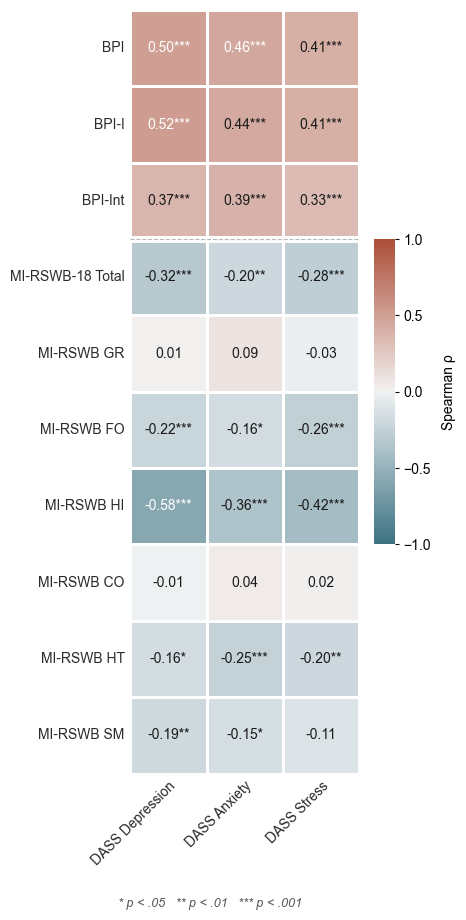

In [43]:
# ── Build pivot matrices for heatmap ─────────────────────────────────────────
row_order = list(PREDICTOR_LABELS.values())
col_order = list(OUTCOME_LABELS.values())

rho_matrix = corr_tbl.pivot(
    index="Predictor", columns="Outcome", values="ρ"
)[col_order].reindex(row_order)

pval_matrix = corr_tbl.pivot(
    index="Predictor", columns="Outcome", values="p_raw"
)[col_order].reindex(row_order)

def _sig_stars(p):
    """Convert p-value to significance stars."""
    if pd.isna(p):   return ""
    if p < 0.001:    return "***"
    if p < 0.01:     return "**"
    if p < 0.05:     return "*"
    return ""

# Annotation: rho on first line, formatted p on second line
def _annot_cell(rho, p_raw):
    stars = _sig_stars(p_raw)
    if pd.isna(rho):
        return ""
    return f"{rho:.2f}{stars}" if stars else f"{rho:.2f}"

annot = pd.DataFrame(
    [[_annot_cell(rho_matrix.loc[r, c], pval_matrix.loc[r, c])
      for c in col_order]
     for r in row_order],
    index=row_order,
    columns=col_order,
)

# ── Rename BPI labels for concise figure display ──────────────────────────────
label_remap = {
    "BPI Mean":          "BPI",
    "BPI-Interference":  "BPI-I",
    "BPI-Intensity":     "BPI-Int",
}
rho_fig   = rho_matrix.rename(index=label_remap)
annot_fig = annot.rename(index=label_remap)
pval_fig  = pval_matrix.rename(index=label_remap)

rho_fig.columns.name  = None
rho_fig.index.name    = None

# ── Global style ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family": "Arial",
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.spines.left":   False,
    "axes.spines.bottom": False,
})

# ── Diverging colormap ─────────────────────────────────────────────────────────
cmap = sns.diverging_palette(220, 20, s=70, l=45, as_cmap=True)

# ── Figure setup ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5.5, 9))

# ── Heatmap ────────────────────────────────────────────────────────────────────
sns.heatmap(
    rho_fig,
    annot=annot_fig,
    fmt="",
    cmap=cmap,
    center=0, vmin=-1, vmax=1,
    linewidths=0.8,
    linecolor="white",
    square=True,
    annot_kws={"size": 10, "weight": "regular"},
    cbar_kws={
        "shrink":      0.40,
        "aspect":      15,
        "pad":         0.03,
        "orientation": "vertical",
    },
    ax=ax
)

# ── Dynamic annotation color: white on dark cells, dark on light cells ─────────
for text in ax.texts:
    xi  = int(text.get_position()[0])   # column index
    yi  = int(text.get_position()[1])   # row index
    val = rho_fig.iloc[yi, xi]
    text.set_color("white" if abs(val) > 0.45 else "#1a1a1a")
    text.set_fontsize(10)

# ── Colorbar styling ───────────────────────────────────────────────────────────
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=10, length=3)
cbar.set_label("Spearman ρ", size=10, labelpad=8)
cbar.set_ticks([-1, -0.5, 0, 0.5, 1])
cbar.outline.set_visible(False)

# ── X-axis: 45° rotation, right-anchored ──────────────────────────────────────
ax.set_xticks(np.arange(rho_fig.shape[1]) + 0.5)
ax.set_xticklabels(
    rho_fig.columns,
    rotation=45,
    ha="right",
    rotation_mode="anchor",
    fontsize=10,
    color="#2b2b2b",
)
ax.tick_params(axis="x", which="both", length=0, pad=4)

# ── Y-axis ─────────────────────────────────────────────────────────────────────
ax.set_yticklabels(
    rho_fig.index,
    rotation=0,
    ha="right",
    fontsize=10,
    color="#2b2b2b",
)
ax.tick_params(axis="y", which="both", length=0, pad=4)

# ── Separator between BPI group (rows 0–2) and MI-RSWB group (rows 3–9) ───────
ax.axhline(y=3, color="white",   linewidth=5,   zorder=3)
ax.axhline(y=3, color="#888888", linewidth=0.8,
           linestyle="--", zorder=4, alpha=0.6)

ax.set_xlabel("")
ax.set_ylabel("")

fig.text(
    0.5, -0.01,
    "* p < .05   ** p < .01   *** p < .001",
    ha="center", va="top",
    fontsize=9, color="#555555",
    style="italic",
)

plt.tight_layout(pad=1.5)
plt.savefig(
    "output/Supplementary_Figure_1.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor(),
)
plt.show()

### OLS ASSUMPTIONS DIAGNOSTICS (Table 3)


OLS ASSUMPTIONS DIAGNOSTICS — Main tertile model (Table 3)


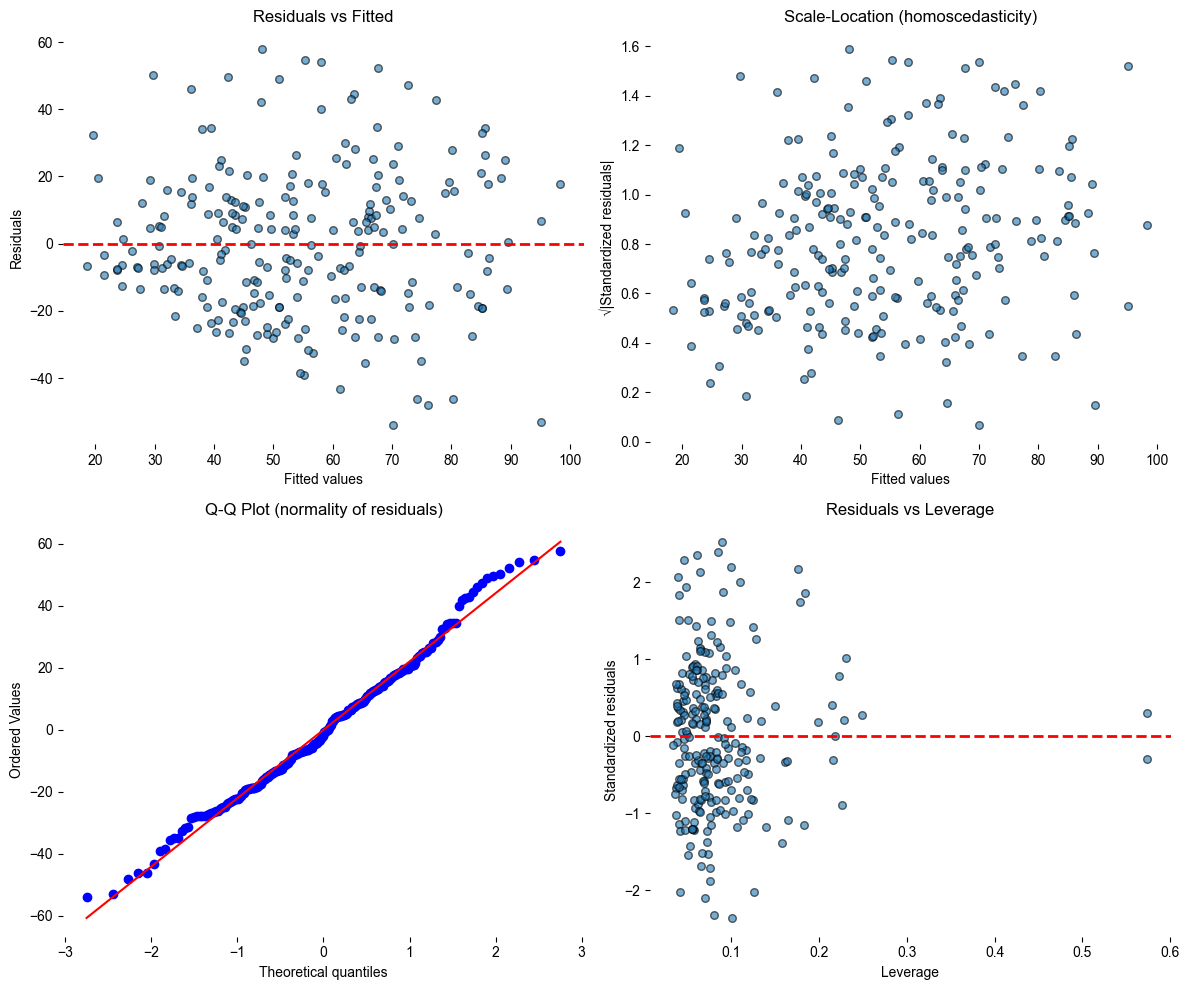


Homoscedasticity — Breusch-Pagan: LM=29.67, p=0.0561
Normality — Shapiro-Wilk:         W=0.9901,  p=0.1102
Normality — Jarque-Bera:          JB=2.58,  p=0.2759

Variance Inflation Factors (centered continuous predictors):


,Variable,VIF
0,genero[T.Masculino],1.21
1,estudios[T. Otros],1.10
2,estudios[T.Estudios de primaria],1.34
3,"estudios[T.Estudios superiores (licenciado, di...",1.51
4,estado_civil[T.Emparejado/a],1.37
5,estado_civil[T.Separado/a],1.15
6,estado_civil[T.Soltero/a],1.35
7,estado_civil[T.Viudo/a],1.36
8,dx_grp[T.Dolor osteomuscular],1.30
9,dx_grp[T.Dolor neuropático],1.21



Max VIF: 2.03  (threshold: >10 = problematic)
Multicollinearity status: ✓  (Max VIF = 2.03)
✓ R² unchanged after centering: 0.371 == 0.371

Diagnostic summary:


,Assumption,Test / Check,Status
0,Linearity,"Residual plots, partial regression",See plots
1,Independence,Cross-sectional design (assumed),✓ assumed
2,Homoscedasticity,"Breusch-Pagan LM=29.67, p=0.056",✓ (HC3 robust SEs used as precaution)
3,Normality (S-W),"Shapiro-Wilk W=0.9901, p=0.110",✓
4,Normality (J-B),"Jarque-Bera JB=2.58, p=0.276",✓
5,No Multicollinearity,Max VIF = 2.03 (centered predictors),✓


In [44]:
# 7. OLS ASSUMPTIONS DIAGNOSTICS (based on main tertile model)
# ============================================================================

print("\n" + "="*60)
print("OLS ASSUMPTIONS DIAGNOSTICS — Main tertile model (Table 3)")
print("="*60)

fitted = m_tertiles.fittedvalues
resid  = m_tertiles.resid
resid_std = m_tertiles.resid_pearson

# ── 7A. Visual diagnostics ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Residuals vs Fitted
axes[0,0].scatter(fitted, resid, alpha=0.6, edgecolors='k', s=30)
axes[0,0].axhline(0, color='red', linestyle='--', lw=2)
axes[0,0].set(xlabel='Fitted values', ylabel='Residuals',
              title='Residuals vs Fitted')

# Scale-Location
axes[0,1].scatter(fitted, np.sqrt(np.abs(resid_std)), alpha=0.6, edgecolors='k', s=30)
axes[0,1].set(xlabel='Fitted values', ylabel='√|Standardized residuals|',
              title='Scale-Location (homoscedasticity)')

# Q-Q plot
stats.probplot(resid, dist="norm", plot=axes[1,0])
axes[1,0].set_title('Q-Q Plot (normality of residuals)')

# Residuals vs Leverage
leverage = OLSInfluence(m_tertiles).hat_matrix_diag
axes[1,1].scatter(leverage, resid_std, alpha=0.6, edgecolors='k', s=30)
axes[1,1].axhline(0, color='red', linestyle='--', lw=2)
axes[1,1].set(xlabel='Leverage', ylabel='Standardized residuals',
              title='Residuals vs Leverage')

plt.tight_layout()
plt.savefig("output/ols_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 7B. Statistical tests ─────────────────────────────────────────────────────
bp_stat, bp_pval, _, _ = het_breuschpagan(resid, m_tertiles.model.exog)
sw_stat, sw_pval       = stats.shapiro(resid)
jb_stat, jb_pval, _, _ = jarque_bera(resid)

print(f"\nHomoscedasticity — Breusch-Pagan: LM={bp_stat:.2f}, p={bp_pval:.4f}")
print(f"Normality — Shapiro-Wilk:         W={sw_stat:.4f},  p={sw_pval:.4f}")
print(f"Normality — Jarque-Bera:          JB={jb_stat:.2f},  p={jb_pval:.4f}")

# ── 7C. VIF for continuous predictors ────────────────────────────────────────
# Rebuild design matrix with CENTERED continuous variables
CONT_VARS = ["bpi_interf_mean", "bpi_int_mean", "mirswb_total",
             "edad", "duracion_dolor"]

rp2_vif = rp2.copy()
for v in CONT_VARS:
    rp2_vif[f"{v}_c"] = rp2_vif[v] - rp2_vif[v].mean()

# Re-fit continuous model with centered predictors (same fit, different scale)
formula_vif = (
    "dass_total_interp ~ "
    "bpi_interf_mean_c + bpi_int_mean_c + mirswb_total_c + "
    "edad_c + duracion_dolor_c + "
    f"C(genero) + {EDU_TERM} + C(estado_civil) + {DX_TERM}"
)
m_vif = smf.ols(formula_vif, data=rp2_vif).fit(cov_type="HC3")

# Extract design matrix WITHOUT intercept column
X_design   = m_vif.model.exog
X_no_int   = X_design[:, 1:]
feat_names = m_vif.model.exog_names[1:]

# Clean up names for display
def clean_vif_name(s):
    s = s.replace('C(genero)', 'genero')
    s = s.replace('C(estado_civil)', 'estado_civil')
    s = s.replace('C(dx_grp, Treatment(reference="Dolor crónico primario"))', 'dx_grp')
    s = s.replace(f'C(estudios, Treatment(reference="{EDU_REF}"))', 'estudios')
    return s

vif_df = pd.DataFrame({
    "Variable": [clean_vif_name(n) for n in feat_names],
    "VIF":      [variance_inflation_factor(X_no_int, i)
                 for i in range(X_no_int.shape[1])]
}).round(2)

print("\nVariance Inflation Factors (centered continuous predictors):")
display(vif_df)

max_vif = vif_df["VIF"].max()
print(f"\nMax VIF: {max_vif:.2f}  (threshold: >10 = problematic)")
print(f"Multicollinearity status: {'✓' if max_vif < 10 else '✗'}  (Max VIF = {max_vif:.2f})")

# Verify centering didn't change model fit
assert abs(m_vif.rsquared - m_continuous.rsquared) < 0.001, \
    "⚠ R² mismatch — centering changed model fit!"
print(f"✓ R² unchanged after centering: {m_vif.rsquared:.3f} == {m_continuous.rsquared:.3f}")

# ── 7D. Summary table ─────────────────────────────────────────────────────────
diag_summary = pd.DataFrame({
    "Assumption":   ["Linearity", "Independence", "Homoscedasticity",
                     "Normality (S-W)", "Normality (J-B)", "No Multicollinearity"],
    "Test / Check": [
        "Residual plots, partial regression",
        "Cross-sectional design (assumed)",
        f"Breusch-Pagan LM={bp_stat:.2f}, p={bp_pval:.3f}",
        f"Shapiro-Wilk W={sw_stat:.4f}, p={sw_pval:.3f}",
        f"Jarque-Bera JB={jb_stat:.2f}, p={jb_pval:.3f}",
        f"Max VIF = {max_vif:.2f} (centered predictors)"
    ],
    "Status": [
        "See plots",
        "✓ assumed",
        "✓ (HC3 robust SEs used as precaution)" if bp_pval < 0.1 else "✓",
        "✓",
        "✓",
        "✓" if max_vif < 10 else "✗",
    ]
})
print("\nDiagnostic summary:")
display(diag_summary)

# Synthetic personas (SPs) analysis

## Master performance table (Task 1–8)

In [45]:
# 8. Master performance table (Steps 1–8)
# ============================================================================
# Builds master_table_round, which is the data source for:
#   - Supplementary Table S6 (R² and RP ceilings)
#   - Supplementary Table S7 (subscale R²)
#   - Figure 1 and Supplementary Figures 1–2
#
# Metrics per step × model:
#   RMSE / MAE  → primary outcome generated in that step
#   R² DASS-21  → pairwise R² on dass_total_interp (NA when DASS-21 is input)
#   R² MI-RSWB  → pairwise R² on mirswb_total      (NA when MI-RSWB is input)
# ============================================================================

# ── Step specifications: inputs, primary outcome, and R² targets ──────────────
STEP_SPECS = {
    "Step 1": dict(datasets=dict(RP=rp, GPT=gpt_step1, DeepSeek=deepseek_step1, Llama=llama_step1),
                   inputs="SocDemo",
                   outcome_col="bpi_mean",        outcome_name="Pain subscale (BPI-11 total)",
                   r2_dass=True,                 r2_mirswb=True),
    "Step 2": dict(datasets=dict(RP=rp, GPT=gpt_step2, DeepSeek=deepseek_step2, Llama=llama_step2),
                   inputs="SocDemo; PDur",
                   outcome_col="bpi_mean",        outcome_name="Pain subscale (BPI-11 total)",
                   r2_dass=True,                 r2_mirswb=True),
    "Step 3": dict(datasets=dict(RP=rp, GPT=gpt_step3, DeepSeek=deepseek_step3, Llama=llama_step3),
                   inputs="SocDemo; Dx",
                   outcome_col="bpi_mean",        outcome_name="Pain subscale (BPI-11 total)",
                   r2_dass=True,                 r2_mirswb=True),
    "Step 4": dict(datasets=dict(RP=rp, GPT=gpt_step4, DeepSeek=deepseek_step4, Llama=llama_step4),
                   inputs="SocDemo; PDur; Dx; BPI-I",
                   outcome_col="bpi_interf_mean", outcome_name="Pain subscale (BPI-Interference)",
                   r2_dass=True,                 r2_mirswb=True),
    "Step 5": dict(datasets=dict(RP=rp, GPT=gpt_step5, DeepSeek=deepseek_step5, Llama=llama_step5),
                   inputs="SocDemo; PDur; Dx; BPI-Int",
                   outcome_col="bpi_int_mean",    outcome_name="Pain subscale (BPI-Intensity)",
                   r2_dass=True,                 r2_mirswb=True),
    "Step 6": dict(datasets=dict(RP=rp, GPT=gpt_step6, DeepSeek=deepseek_step6, Llama=llama_step6),
                   inputs="SocDemo; PDur; Dx; BPI-11",
                   outcome_col="dass_total_interp", outcome_name="DASS-21 (total)",
                   r2_dass=True,                    r2_mirswb=True),
    "Step 7": dict(datasets=dict(RP=rp, GPT=gpt_step7, DeepSeek=deepseek_step7, Llama=llama_step7),
                   inputs="SocDemo; PDur; Dx; BPI-11; MI-RSWB-18",
                   outcome_col="dass_total_interp", outcome_name="DASS-21 (total)",
                   r2_dass=True,  r2_mirswb=False),  # MI-RSWB-18 is input → R² N/A
    "Step 8": dict(datasets=dict(RP=rp, GPT=gpt_step8, DeepSeek=deepseek_step8, Llama=llama_step8),
                   inputs="SocDemo; PDur; Dx; BPI-11; DASS-21",
                   outcome_col="mirswb_total",    outcome_name="MI-RSWB-18 (total)",
                   r2_dass=False, r2_mirswb=True),  # DASS-21 is input → R² N/A
}

# ── Subscale columns for extended R² tracking ────────────────────────────────
DASS_SUB_COLS    = {"Depression": "dass_dep_interp",
                    "Anxiety":    "dass_ans_interp",
                    "Stress":     "dass_st_interp"}
MIRSWB_SUB_COLS  = {"GR":      "mirswb_gr",
                    "FO": "mirswb_fo",
                    "HI":        "mirswb_hi",
                    "CO":  "mirswb_co",
                    "HT":   "mirswb_ht",
                    "SM":     "mirswb_sm"}


def _pairwise_r2(rp_df, sp_df, col):
    """R² between RP and SP on col, matched row-for-row (assumes same order)."""
    if col not in rp_df.columns or col not in sp_df.columns:
        return np.nan
    y_true = rp_df[col].values.astype(float)
    y_pred = sp_df[col].values.astype(float)
    mask   = np.isfinite(y_true) & np.isfinite(y_pred)
    if mask.sum() < 10:
        return np.nan
    return r2_score(y_true[mask], y_pred[mask])


def _pairwise_rmse_mae(rp_df, sp_df, col):
    """RMSE and MAE between RP and SP on col, matched row-for-row."""
    if col not in rp_df.columns or col not in sp_df.columns:
        return np.nan, np.nan
    y_true = rp_df[col].values.astype(float)
    y_pred = sp_df[col].values.astype(float)
    mask   = np.isfinite(y_true) & np.isfinite(y_pred)
    if mask.sum() < 10:
        return np.nan, np.nan
    return (np.sqrt(mean_squared_error(y_true[mask], y_pred[mask])),
            mean_absolute_error(y_true[mask], y_pred[mask]))


# ── Build master table ────────────────────────────────────────────────────────
rows = []
for step_name, spec in STEP_SPECS.items():
    rp_df   = spec["datasets"]["RP"]
    out_col = spec["outcome_col"]
    rp_mean = rp_df[out_col].mean() if out_col in rp_df.columns else np.nan

    for model in ["GPT", "DeepSeek", "Llama"]:
        sp_df   = spec["datasets"][model]
        sp_mean = sp_df[out_col].mean() if out_col in sp_df.columns else np.nan
        delta   = ((sp_mean - rp_mean) / rp_mean * 100) if pd.notna(rp_mean) else np.nan
        rmse, mae = _pairwise_rmse_mae(rp_df, sp_df, out_col)

        row = {
            "Step":                    step_name,
            "Model":                   model,
            "Inputs provided":         spec["inputs"],
            "Outcome generated":       spec["outcome_name"],
            "RP mean":                 rp_mean,
            "SP mean":                 sp_mean,
            "ΔMean (%)":              delta,
            "RMSE":                    rmse,
            "MAE":                     mae,
            "R² (DASS-21 outcome)":   _pairwise_r2(rp_df, sp_df, "dass_total_interp")
                                        if spec["r2_dass"] else np.nan,
            "R² (MI-RSWB-18 outcome)": _pairwise_r2(rp_df, sp_df, "mirswb_total")
                                        if spec["r2_mirswb"] else np.nan,
        }
        # DASS-21 subscales
        for label, col in DASS_SUB_COLS.items():
            row[f"R² (DASS-21 {label})"] = (
                _pairwise_r2(rp_df, sp_df, col) if spec["r2_dass"] else np.nan
            )
        # MI-RSWB subscales
        for label, col in MIRSWB_SUB_COLS.items():
            row[f"R² (MI-RSWB {label})"] = (
                _pairwise_r2(rp_df, sp_df, col) if spec["r2_mirswb"] else np.nan
            )
        rows.append(row)

# Sort and round
step_order  = [f"Step {i}" for i in range(1, 9)]
model_order = ["GPT", "DeepSeek", "Llama"]

master_table_round = (
    pd.DataFrame(rows)
    .assign(Step  = lambda d: pd.Categorical(d["Step"],  categories=step_order,  ordered=True),
            Model = lambda d: pd.Categorical(d["Model"], categories=model_order, ordered=True))
    .sort_values(["Step", "Model"])
    .reset_index(drop=True)
)

num_cols = master_table_round.select_dtypes(include="number").columns
master_table_round[num_cols] = master_table_round[num_cols].round(2)

display(master_table_round)
print(f"\n✓ master_table_round ready: {master_table_round.shape[0]} rows × {master_table_round.shape[1]} cols")
print(f"  Subscale R² columns included: DASS-21 ({len(DASS_SUB_COLS)}) + MI-RSWB ({len(MIRSWB_SUB_COLS)})")

,Step,Model,Inputs provided,Outcome generated,RP mean,SP mean,ΔMean (%),RMSE,MAE,R² (DASS-21 outcome),R² (MI-RSWB-18 outcome),R² (DASS-21 Depression),R² (DASS-21 Anxiety),R² (DASS-21 Stress),R² (MI-RSWB GR),R² (MI-RSWB FO),R² (MI-RSWB HI),R² (MI-RSWB CO),R² (MI-RSWB HT),R² (MI-RSWB SM)
0,Step 1,GPT,SocDemo,Pain subscale (BPI-11 total),6.60,5.57,-15.66,2.00,1.64,-0.05,-0.25,-0.08,-0.10,-0.16,-0.39,-0.60,-0.61,-0.09,-0.61,-0.01
1,Step 1,DeepSeek,SocDemo,Pain subscale (BPI-11 total),6.60,6.25,-5.38,1.77,1.42,-0.17,-0.24,-0.29,-0.42,-0.47,-1.99,-0.72,-0.22,-1.06,-2.07,-0.20
2,Step 1,Llama,SocDemo,Pain subscale (BPI-11 total),6.60,5.71,-13.52,1.94,1.60,-0.07,-1.39,-0.20,-0.10,-0.15,-1.45,-1.06,-2.42,-0.35,-0.83,-0.27
3,Step 2,GPT,SocDemo; PDur,Pain subscale (BPI-11 total),6.60,5.55,-15.91,2.03,1.67,-0.07,-0.27,-0.16,-0.10,-0.17,-0.48,-0.62,-0.53,-0.15,-0.52,-0.09
4,Step 2,DeepSeek,SocDemo; PDur,Pain subscale (BPI-11 total),6.60,6.28,-4.86,1.73,1.40,-0.15,-0.32,-0.38,-0.32,-0.43,-1.86,-0.69,-0.15,-1.10,-2.14,-0.19
5,Step 2,Llama,SocDemo; PDur,Pain subscale (BPI-11 total),6.60,5.64,-14.56,2.00,1.66,-0.10,-1.41,-0.20,-0.25,-0.10,-1.52,-1.06,-2.45,-0.39,-0.67,-0.44
6,Step 3,GPT,SocDemo; Dx,Pain subscale (BPI-11 total),6.60,5.57,-15.69,2.02,1.66,-0.06,-0.27,-0.09,-0.16,-0.13,-0.54,-0.55,-0.53,-0.14,-0.65,-0.02
7,Step 3,DeepSeek,SocDemo; Dx,Pain subscale (BPI-11 total),6.60,6.33,-4.13,1.73,1.38,-0.12,-0.50,-0.25,-0.51,-0.37,-1.83,-0.63,-0.21,-1.35,-1.89,-0.32
8,Step 3,Llama,SocDemo; Dx,Pain subscale (BPI-11 total),6.60,5.78,-12.43,1.90,1.57,-0.07,-1.43,-0.20,-0.13,-0.07,-1.45,-1.08,-2.52,-0.31,-0.90,-0.29
9,Step 4,GPT,SocDemo; PDur; Dx; BPI-I,Pain subscale (BPI-Interference),6.82,5.98,-12.24,1.67,1.37,0.09,-0.36,0.03,-0.00,-0.03,-0.59,-0.52,-0.60,-0.14,-0.52,-0.00



✓ master_table_round ready: 24 rows × 20 cols
  Subscale R² columns included: DASS-21 (3) + MI-RSWB (6)


### FIGURE 1

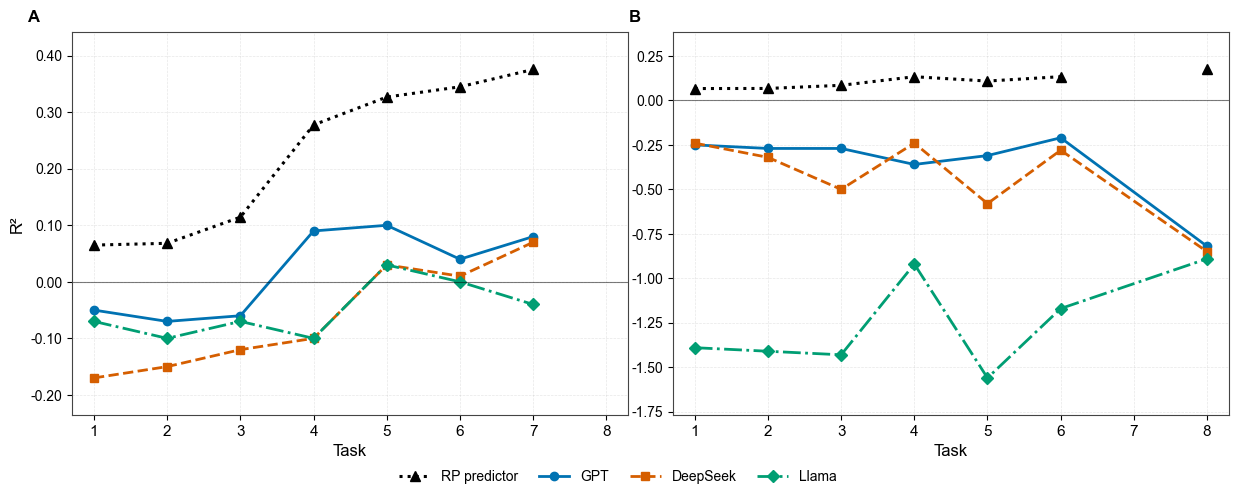

✓ Saved: output/Figure_1.png


In [46]:
# 9. FIGURE 1 — R² vs Task (DASS-21 and MI-RSWB-18 total scores)
# ============================================================================

# Okabe-Ito colorblind-safe palette
OKABE_ITO = {
    "GPT":          "#0072B2",
    "DeepSeek":     "#D55E00",
    "Llama":        "#009E73",
    "RP predictor": "#000000",
}
MARKERS    = {"GPT": "o", "DeepSeek": "s", "Llama": "D", "RP predictor": "^"}
LINESTYLES = {"GPT": "-", "DeepSeek": "--", "Llama": "-.", "RP predictor": ":"}
MODEL_ORDER = ["GPT", "DeepSeek", "Llama"]


def compute_rp_r2_ols(rp_df, cont_cols, cat_cols, outcome_col):
    """
    Fit an in-sample OLS model on RP data and return R² as the step-specific
    performance ceiling.
    """
    df = rp_df.copy()
    if df.columns.duplicated().any():
        df = df.loc[:, ~df.columns.duplicated(keep="first")]
    avail_cont = [c for c in cont_cols if c in df.columns]
    avail_cat  = [c for c in cat_cols  if c in df.columns]
    if outcome_col not in df.columns:
        return np.nan
    df = df[avail_cont + avail_cat + [outcome_col]].dropna()
    if len(df) < 20:
        return np.nan
    parts = []
    if avail_cont:
        parts.append(df[avail_cont].astype(float))
    if avail_cat:
        parts.append(pd.get_dummies(df[avail_cat], drop_first=True).astype(float))
    X = sm.add_constant(pd.concat(parts, axis=1), has_constant="add")
    y = df[outcome_col].astype(float)
    data = pd.concat([X, y.rename("_y_")], axis=1).dropna()
    return sm.OLS(data["_y_"], data.drop(columns="_y_")).fit().rsquared


def _rp_series(rp_r2_dict, step_names):
    """Return RP R² values as an ordered list aligned to step_names."""
    return [rp_r2_dict.get(s, np.nan) for s in step_names]


def _extract_step_num(df):
    """Extract the integer step number from Step label strings."""
    return df["Step"].astype(str).str.extract(r"(\d+)").astype(float)


# ── Sociodemographic categorical covariates shared across all steps ───────────
_SOCDEMO_CAT = ["genero", "estado_civil", "estudios"]

# ── RP input specifications for DASS-21 ceiling computation ──────────────────
# Step 8 is excluded because DASS-21 is the input (not the outcome) in that step
STEP_RP_INPUTS_DASS = {
    "Step 1": {"cont": ["edad"],                                                              "cat": _SOCDEMO_CAT},
    "Step 2": {"cont": ["edad", "duracion_dolor"],                                            "cat": _SOCDEMO_CAT},
    "Step 3": {"cont": ["edad"],                                                              "cat": _SOCDEMO_CAT + ["causa_dolor"]},
    "Step 4": {"cont": ["edad", "duracion_dolor", "bpi_int_mean"],                           "cat": _SOCDEMO_CAT + ["causa_dolor"]},
    "Step 5": {"cont": ["edad", "duracion_dolor", "bpi_interf_mean"],                        "cat": _SOCDEMO_CAT + ["causa_dolor"]},
    "Step 6": {"cont": ["edad", "duracion_dolor", "bpi_interf_mean", "bpi_int_mean"],        "cat": _SOCDEMO_CAT + ["causa_dolor"]},
    "Step 7": {"cont": ["edad", "duracion_dolor", "bpi_interf_mean", "bpi_int_mean",
                        "mirswb_total"],                                                      "cat": _SOCDEMO_CAT + ["causa_dolor"]},
}

# ── RP input specifications for MI-RSWB-18 ceiling computation ───────────────
# Step 7 is excluded because MI-RSWB-18 is the input (not the outcome) in that step
STEP_RP_INPUTS_MIRSWB = {
    "Step 1": {"cont": ["edad"],                                                              "cat": _SOCDEMO_CAT},
    "Step 2": {"cont": ["edad", "duracion_dolor"],                                            "cat": _SOCDEMO_CAT},
    "Step 3": {"cont": ["edad"],                                                              "cat": _SOCDEMO_CAT + ["causa_dolor"]},
    "Step 4": {"cont": ["edad", "duracion_dolor", "bpi_int_mean"],                           "cat": _SOCDEMO_CAT + ["causa_dolor"]},
    "Step 5": {"cont": ["edad", "duracion_dolor", "bpi_interf_mean"],                        "cat": _SOCDEMO_CAT + ["causa_dolor"]},
    "Step 6": {"cont": ["edad", "duracion_dolor", "bpi_interf_mean", "bpi_int_mean"],        "cat": _SOCDEMO_CAT + ["causa_dolor"]},
    "Step 8": {"cont": ["edad", "duracion_dolor", "bpi_interf_mean", "bpi_int_mean",
                        "dass_total_interp"],                                                 "cat": _SOCDEMO_CAT + ["causa_dolor"]},
}

STEP_NAMES = [f"Step {i}" for i in range(1, 9)]

# ── Compute RP ceiling R² for each step ──────────────────────────────────────
rp_r2_dass_dict = {
    s: compute_rp_r2_ols(rp, v["cont"], v["cat"], outcome_col="dass_total_interp")
    for s, v in STEP_RP_INPUTS_DASS.items()
}
rp_r2_dass_dict["Step 8"] = np.nan   # DASS-21 is input in Step 8

rp_r2_mirswb_dict = {
    s: compute_rp_r2_ols(rp, v["cont"], v["cat"], outcome_col="mirswb_total")
    for s, v in STEP_RP_INPUTS_MIRSWB.items()
}
rp_r2_mirswb_dict["Step 7"] = np.nan  # MI-RSWB-18 is input in Step 7

rp_dass   = np.array(_rp_series(rp_r2_dass_dict,   STEP_NAMES))
rp_mirswb = np.array(_rp_series(rp_r2_mirswb_dict, STEP_NAMES))


# ── Panel rendering function ──────────────────────────────────────────────────
def _panel(ax, df, r2_col, rp_y, step_min, step_max, ylabel=False):
    """
    Render one R²-vs-step panel for a given outcome column.

    Parameters
    ----------
    ax       : Matplotlib Axes object
    df       : master_table_round DataFrame
    r2_col   : column name for the R² values to plot
    rp_y     : full-length RP ceiling array (Steps 1–8)
    step_min : first step number to display
    step_max : last step number to display
    ylabel   : whether to draw the y-axis label
    """
    d = df.copy()
    d["Step_num"] = _extract_step_num(d).astype("Int64")
    d = d.dropna(subset=["Step_num", r2_col])
    d[r2_col] = pd.to_numeric(d[r2_col], errors="coerce")

    steps   = np.arange(step_min, step_max + 1)
    rp_plot = np.asarray(rp_y, dtype=float)[step_min - 1:step_max]

    # ── RP ceiling line ───────────────────────────────────────────────────────
    ax.plot(
        steps, rp_plot,
        marker=MARKERS["RP predictor"], linestyle=LINESTYLES["RP predictor"],
        linewidth=2.2, markersize=6.5, color=OKABE_ITO["RP predictor"],
        label="RP predictor"
    )

    # ── Synthetic model lines ─────────────────────────────────────────────────
    for m in MODEL_ORDER:
        g = d[d["Model"] == m].sort_values("Step_num")
        if g.empty:
            continue
        ax.plot(
            g["Step_num"].astype(int), g[r2_col].to_numpy(dtype=float),
            marker=MARKERS[m], linestyle=LINESTYLES[m],
            linewidth=2, markersize=6, color=OKABE_ITO[m], label=m
        )

    # ── Reference line at R² = 0 ─────────────────────────────────────────────
    ax.axhline(0, color="black", linewidth=0.8, alpha=0.5)

    # ── Axes configuration ───────────────────────────────────────────────────
    ax.set_xlim(step_min - 0.3, step_max + 0.3)
    ax.set_xticks(range(step_min, step_max + 1))
    ax.set_xticklabels([str(i) for i in range(step_min, step_max + 1)], fontsize=11)
    ax.tick_params(axis="y", labelsize=11)
    ax.set_xlabel("Task", fontsize=12)

    # Per-panel y-limits derived from visible data only
    visible_vals = np.concatenate([
        d[r2_col].dropna().values,
        rp_plot[np.isfinite(rp_plot)]
    ])
    if len(visible_vals):
        ymin = min(float(np.min(visible_vals)), 0.0)
        ymax = max(float(np.max(visible_vals)), 0.0)
        span = (ymax - ymin) or 1.0
        ax.set_ylim(ymin - 0.12 * span, ymax + 0.12 * span)

    # Y-tick formatting
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.2f}"))
    ax.tick_params(axis="y", labelsize=10)

    if ylabel:
        ax.set_ylabel("R²", fontsize=12)

    # ── Border box ───────────────────────────────────────────────────────────
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)
        spine.set_color("#444444")

    ax.grid(True, linewidth=0.5, alpha=0.3, linestyle="--")


# ── Build figure ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":      "sans-serif",
    "font.sans-serif":  ["Arial"],
})

fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(13, 4.5))

_panel(ax_a, master_table_round, "R² (DASS-21 outcome)",
       rp_dass,   step_min=1, step_max=8, ylabel=True)

_panel(ax_b, master_table_round, "R² (MI-RSWB-18 outcome)",
       rp_mirswb, step_min=1, step_max=8, ylabel=False)

# ── Panel labels (A / B) ─────────────────────────────────────────────────────
for ax, lbl in zip([ax_a, ax_b], ["A", "B"]):
    ax.text(-0.08, 1.02, lbl, transform=ax.transAxes,
            fontsize=12, fontweight="bold", va="bottom")

# ── Shared horizontal legend below both panels ───────────────────────────────
handles, labels = ax_a.get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center",
    ncol=len(labels),
    frameon=False,
    fontsize=10,
    bbox_to_anchor=(0.5, -0.08),
    handlelength=2.2,
    columnspacing=1.5,
)

fig.subplots_adjust(
    left=0.08, right=0.97,
    top=0.95,  bottom=0.10,
    hspace=0.45,    
    wspace=0.08,
)
fig.savefig("output/Figure_1.png", dpi=300, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("✓ Saved: output/Figure_1.png")

### SUPPLEMENTARY FIGURE 1

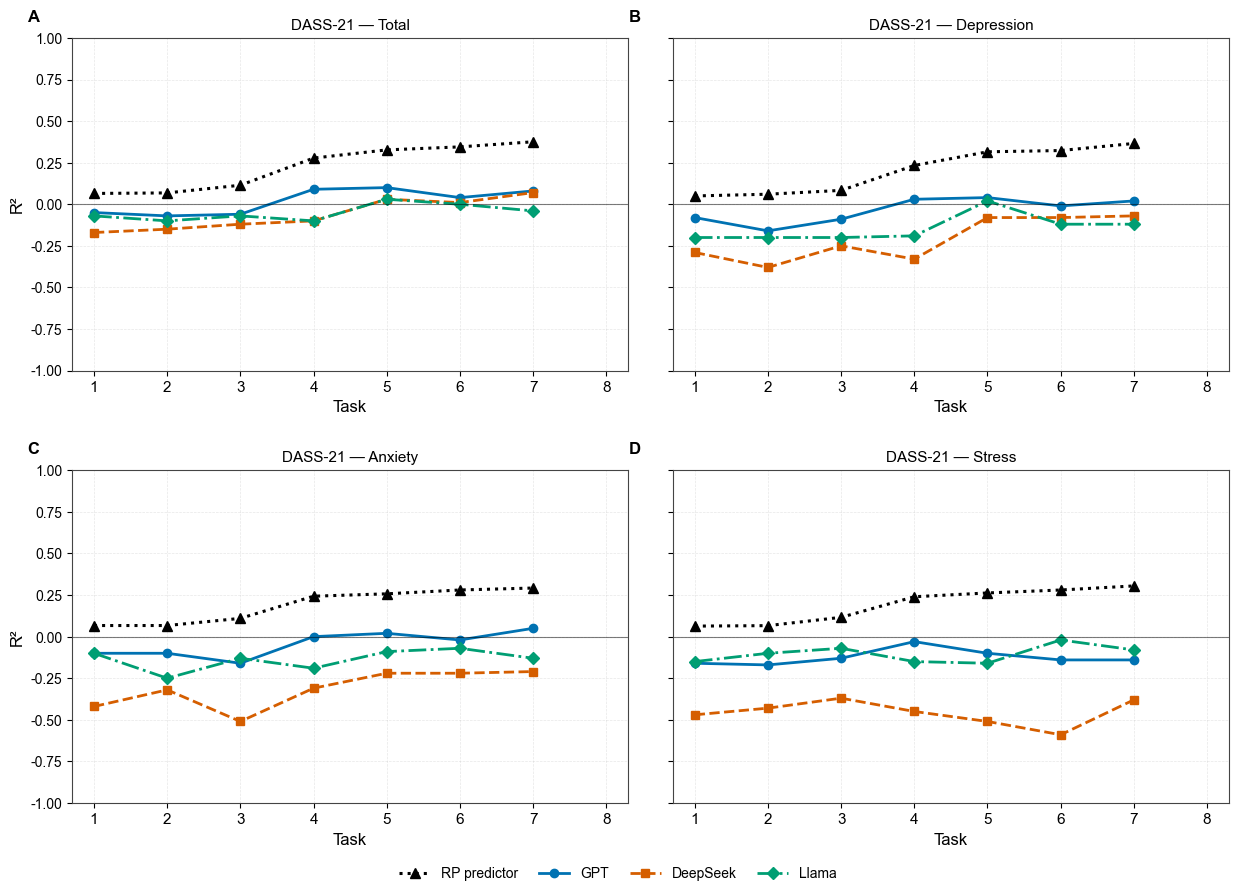

✓ Saved: output/Supplementary_Figure_2.png


In [47]:
# 10. SUPPLEMENTARY FIGURE 2 — R² across tasks for DASS-21 total and subscale scores
# (2×2 panel: Total, Depression, Anxiety, Stress)
# Steps 1–7 only; Step 8 is excluded because DASS-21 serves as model input
# ============================================================================

def _compute_shared_ylims(df, r2_cols, step_min=1, step_max=8, pad=0.15, rp_series_dict=None):
    """
    Compute shared y-limits across multiple R² columns, optionally including external RP predictor series.
    Ignores NaNs, applies symmetric padding, and always includes 0.
    """
    d = df.copy()
    d["Step_num"] = d["Step"].astype(str).str.extract(r"(\d+)").astype(float)
    d = d.dropna(subset=["Step_num"])
    d["Step_num"] = d["Step_num"].astype(int)
    d = d[(d["Step_num"] >= step_min) & (d["Step_num"] <= step_max)]

    vals = []
    for col in r2_cols:
        if col in d.columns:
            vals.append(pd.to_numeric(d[col], errors="coerce").to_numpy())

    if rp_series_dict:
        for _, series in rp_series_dict.items():
            arr = np.asarray(series, dtype=float)
            vals.append(arr)

    if not vals:
        return None

    y = np.concatenate(vals)
    y = y[np.isfinite(y)]
    if y.size == 0:
        return None

    ymin, ymax = float(np.min(y)), float(np.max(y))
    ymin = min(ymin, 0.0)
    ymax = max(ymax, 0.0)

    span = ymax - ymin
    if span == 0:
        span = 1.0
    ymin -= pad * span
    ymax += pad * span

    ymin = np.floor(ymin * 2) / 2
    ymax = np.ceil(ymax * 2) / 2
    return (ymin, ymax)

# Map each subscale label to its master_table R² column and outcome column
DASS_SUBS = {
    "Total":      ("R² (DASS-21 outcome)",    "dass_total_interp"),
    "Depression": ("R² (DASS-21 Depression)", "dass_dep_interp"),
    "Anxiety":    ("R² (DASS-21 Anxiety)",    "dass_ans_interp"),
    "Stress":     ("R² (DASS-21 Stress)",     "dass_st_interp"),
}

# ── Compute RP ceiling R² for each DASS subscale across all steps ─────────────
rp_r2_dass_subs = {}
for label, (_, outcome_col) in DASS_SUBS.items():
    d = {
        s: compute_rp_r2_ols(rp, v["cont"], v["cat"], outcome_col=outcome_col)
        for s, v in STEP_RP_INPUTS_DASS.items()
    }
    d["Step 8"] = np.nan   # DASS-21 is input in Step 8, ceiling undefined
    rp_r2_dass_subs[label] = np.array(_rp_series(d, STEP_NAMES))

# ── Shared y-limits across all 4 panels ──────────────────────────────────────
sf2_ylims = _compute_shared_ylims(
    master_table_round,
    r2_cols=[r2_col for _, (r2_col, _) in DASS_SUBS.items()],
    step_min=1,
    step_max=8,
    pad=0.15,
    rp_series_dict=rp_r2_dass_subs,
)

# ── Figure layout ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":      "sans-serif",
    "font.sans-serif":  ["Arial"],
})

fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharey=True)
fig.patch.set_facecolor("white")

panel_labels = ["A", "B", "C", "D"]

for (ax, (label, (r2_col, _)), panel_lbl) in zip(
    axes.flatten(), DASS_SUBS.items(), panel_labels
):
    ax.set_facecolor("white")

    # Render panel using shared helper (no legend inside panels)
    _panel(
        ax, master_table_round, r2_col,
        rp_r2_dass_subs[label],
        step_min=1, step_max=8,
        ylabel=(ax in axes[:, 0]),
    )

    # Apply shared y-limits for visual comparability across panels
    ax.set_ylim(*sf2_ylims)

    # Subtitle per panel (kept as requested)
    ax.set_title(f"DASS-21 — {label}", fontsize=11, pad=6)

    # Bold panel letter (A, B, C, D) in upper-left corner
    ax.text(
        -0.08, 1.04, panel_lbl,
        transform=ax.transAxes,
        fontsize=12, fontweight="bold", va="bottom"
    )

    # Visible border box around each panel
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)
        spine.set_color("#444444")

# ── Shared horizontal legend below all panels ─────────────────────────────────
handles, labels = axes.flatten()[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center",
    ncol=len(labels),
    frameon=False,
    fontsize=10,
    bbox_to_anchor=(0.5, 0.0),
    handlelength=2.2,
    columnspacing=1.5,
)

fig.subplots_adjust(
    left=0.08, right=0.97,
    top=0.95,  bottom=0.10,
    hspace=0.3,    
    wspace=0.08,
)

fig.savefig(
    "output/Supplementary_Figure_2.png",
    dpi=300, bbox_inches="tight",
    facecolor="white"
)
plt.show()
print("✓ Saved: output/Supplementary_Figure_2.png")

### SUPPLEMENTARY FIGURE 2

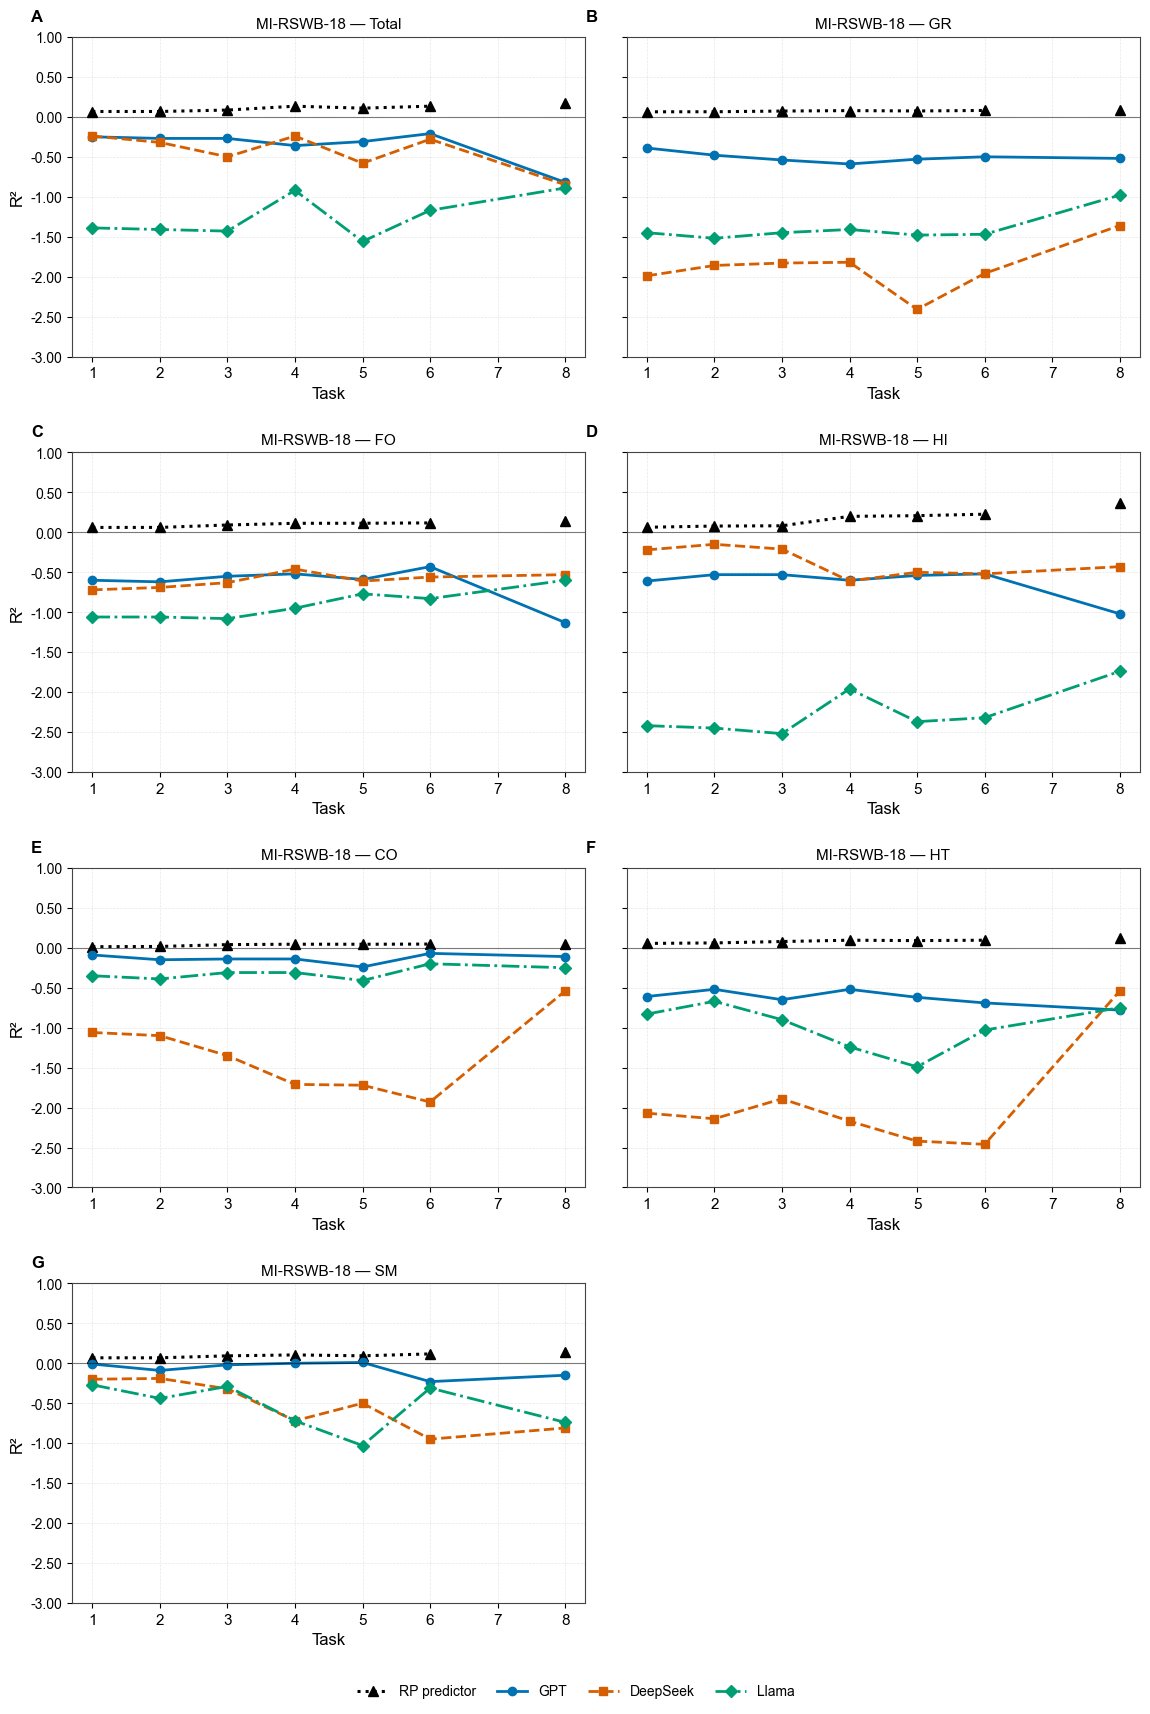

✓ Saved: output/Supplementary_Figure_3.png


In [48]:
# 11. SUPPLEMENTARY FIGURE 3 — R² across tasks for MI-RSWB-18 total and subscale scores
# ============================================================================

# Map each subscale label to its master_table R² column and outcome column
MIRSWB_SUBS = {
    "Total":       ("R² (MI-RSWB-18 outcome)", "mirswb_total"),
    "GR":          ("R² (MI-RSWB GR)",          "mirswb_gr"),
    "FO":          ("R² (MI-RSWB FO)",          "mirswb_fo"),
    "HI":          ("R² (MI-RSWB HI)",          "mirswb_hi"),
    "CO":          ("R² (MI-RSWB CO)",          "mirswb_co"),
    "HT":          ("R² (MI-RSWB HT)",          "mirswb_ht"),
    "SM":          ("R² (MI-RSWB SM)",          "mirswb_sm"),
}

# ── Compute RP ceiling R² for each MI-RSWB subscale across all steps ──────────
rp_r2_mirswb_subs = {}
for label, (_, outcome_col) in MIRSWB_SUBS.items():
    d = {
        s: compute_rp_r2_ols(rp, v["cont"], v["cat"], outcome_col=outcome_col)
        for s, v in STEP_RP_INPUTS_MIRSWB.items()
    }
    d["Step 7"] = np.nan   # MI-RSWB-18 is input in Step 7, ceiling undefined
    rp_r2_mirswb_subs[label] = np.array(_rp_series(d, STEP_NAMES))

# ── Shared y-limits across all 7 panels ──────────────────────────────────────
sf3_ylims = _compute_shared_ylims(
    master_table_round,
    r2_cols=[r2_col for _, (r2_col, _) in MIRSWB_SUBS.items()],
    step_min=1,
    step_max=8,
    pad=0.15,
    rp_series_dict=rp_r2_mirswb_subs,
)

# ── Figure layout: 4×2 grid (7 panels; last cell hidden) ─────────────────────
plt.rcParams.update({
    "font.family":      "sans-serif",
    "font.sans-serif":  ["Arial"],
})

fig, axes = plt.subplots(4, 2, figsize=(12, 18), sharey=True)
fig.patch.set_facecolor("white")
axes_flat = axes.flatten()

panel_labels = ["A", "B", "C", "D", "E", "F", "G"]

for ax, (label, (r2_col, _)), panel_lbl in zip(
    axes_flat, MIRSWB_SUBS.items(), panel_labels
):
    ax.set_facecolor("white")

    # Render panel using shared helper (no legend inside panels)
    _panel(
        ax, master_table_round, r2_col,
        rp_r2_mirswb_subs[label],
        step_min=1, step_max=8,
        ylabel=(ax in axes[:, 0]),
    )

    # Apply shared y-limits for visual comparability across all panels
    ax.set_ylim(*sf3_ylims)

    # Subtitle per panel
    ax.set_title(f"MI-RSWB-18 — {label}", fontsize=11, pad=6)

    # Bold panel letter in upper-left corner
    ax.text(
        -0.08, 1.04, panel_lbl,
        transform=ax.transAxes,
        fontsize=12, fontweight="bold", va="bottom"
    )

    # Visible border box around each panel
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)
        spine.set_color("#444444")

# ── Hide the unused 8th cell in the 4×2 grid ─────────────────────────────────
axes_flat[-1].set_visible(False)

# ── Shared horizontal legend below all panels ─────────────────────────────────
# Retrieve handles from the first active panel
handles, labels = axes_flat[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center",
    ncol=len(labels),
    frameon=False,
    fontsize=10,
    bbox_to_anchor=(0.5, 0.02),
    handlelength=2.2,
    columnspacing=1.5,
)

fig.subplots_adjust(
    left=0.08, right=0.97,
    top=0.95,  bottom=0.08,
    hspace=0.3,    
    wspace=0.08,
)

fig.savefig(
    "output/Supplementary_Figure_3.png",
    dpi=300, bbox_inches="tight",
    facecolor="white"
)
plt.show()
print("✓ Saved: output/Supplementary_Figure_3.png")

### TABLE 4

In [49]:
# 12. TABLE 4 — Mean-level fidelity: ΔMean% and RMSE for DASS-21 and MI-RSWB-18
# ============================================================================

# ── Helper: pairwise RMSE and MAE ────────────────────────────────────────────
def _pairwise_rmse_mae(rp_df: pd.DataFrame, sp_df: pd.DataFrame, col: str):
    if col not in rp_df.columns or col not in sp_df.columns:
        return np.nan, np.nan
    y_true = rp_df[col].values.astype(float)
    y_pred = sp_df[col].values.astype(float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if mask.sum() < 10:
        return np.nan, np.nan
    return (float(np.sqrt(mean_squared_error(y_true[mask], y_pred[mask]))),
            float(mean_absolute_error(y_true[mask], y_pred[mask])))


# ── Step registry ─────────────────────────────────────────────────────────────
# None → variable is INPUT at that step (not generated → no ΔMean / RMSE)
STEP_REGISTRY = {
    "Step 1": {"dass": "dass_total_interp", "mirswb": "mirswb_total",
               "bpi": "bpi_mean",          # full BPI generated
               "dfs": {"GPT": gpt_step1, "DeepSeek": deepseek_step1, "Llama": llama_step1}},
    "Step 2": {"dass": "dass_total_interp", "mirswb": "mirswb_total",
               "bpi": "bpi_mean",          # full BPI generated
               "dfs": {"GPT": gpt_step2, "DeepSeek": deepseek_step2, "Llama": llama_step2}},
    "Step 3": {"dass": "dass_total_interp", "mirswb": "mirswb_total",
               "bpi": "bpi_mean",          # full BPI generated
               "dfs": {"GPT": gpt_step3, "DeepSeek": deepseek_step3, "Llama": llama_step3}},
    "Step 4": {"dass": "dass_total_interp", "mirswb": "mirswb_total",
               "bpi": "bpi_interf_mean",   # Intensity is input → Interference is generated
               "dfs": {"GPT": gpt_step4, "DeepSeek": deepseek_step4, "Llama": llama_step4}},
    "Step 5": {"dass": "dass_total_interp", "mirswb": "mirswb_total",
               "bpi": "bpi_int_mean",      # Interference is input → Intensity is generated
               "dfs": {"GPT": gpt_step5, "DeepSeek": deepseek_step5, "Llama": llama_step5}},
    "Step 6": {"dass": "dass_total_interp", "mirswb": "mirswb_total",
               "bpi": None,                # full BPI = input
               "dfs": {"GPT": gpt_step6, "DeepSeek": deepseek_step6, "Llama": llama_step6}},
    "Step 7": {"dass": "dass_total_interp", "mirswb": None,
               "bpi": None,                # MI-RSWB + BPI = input
               "dfs": {"GPT": gpt_step7, "DeepSeek": deepseek_step7, "Llama": llama_step7}},
    "Step 8": {"dass": None,               "mirswb": "mirswb_total",
               "bpi": None,                # DASS + BPI = input
               "dfs": {"GPT": gpt_step8, "DeepSeek": deepseek_step8, "Llama": llama_step8}},
}

STEP_NAMES  = [f"Step {i}" for i in range(1, 9)]
MODEL_ORDER = ["GPT", "DeepSeek", "Llama"]

# ── Additional variables tracked in Supplementary Tables S9–S10 ──────────────
SUPP_VARS = {
    "Pain duration (years)":  "duracion_dolor",
    "BPI-Intensity":          "bpi_int_mean",       
    "BPI-Interference":       "bpi_interf_mean",    
    "MI-RSWB-18 total":       "mirswb_total",
    "DASS-21 total":          "dass_total_interp",
    "Depression subscale":    "dass_dep_interp",
    "Anxiety subscale":       "dass_ans_interp",
    "Stress subscale":        "dass_st_interp",
    "Gratitude subscale":     "mirswb_ht",
    "Forgiveness subscale":   "mirswb_fo",
    "Hope subscale":          "mirswb_hi",
    "Connection subscale":    "mirswb_co",
    "Transcendence subscale": "mirswb_gr",
    "Meaning subscale":       "mirswb_sm",
}

# ── Variables that are INPUT (not generated) at each step ────────────────────
# These are marked as [input] in the paper tables
SUPP_INPUT_MAP = {
    "Step 2": {"duracion_dolor"},
    "Step 3": set(),
    "Step 4": {"duracion_dolor", "bpi_int_mean"},          
    "Step 5": {"duracion_dolor", "bpi_interf_mean"},             
    "Step 6": {"duracion_dolor", "bpi_mean",
               "bpi_interf_mean", "bpi_int_mean"},
    "Step 7": {"duracion_dolor", "bpi_mean",
               "bpi_interf_mean", "bpi_int_mean",
               "mirswb_total", "mirswb_gr", "mirswb_fo",
               "mirswb_hi", "mirswb_co", "mirswb_ht", "mirswb_sm"},
    "Step 8": {"duracion_dolor", "bpi_mean",
               "bpi_interf_mean", "bpi_int_mean",
               "dass_total_interp", "dass_dep_interp",
               "dass_ans_interp",   "dass_st_interp"},
}

print("=" * 70)
print("TABLE 4 — Mean-level fidelity (DASS-21 and MI-RSWB-18, Steps 1–8)")
print("=" * 70)

table4_rows = []

for step_name, cfg in STEP_REGISTRY.items():
    dass_col   = cfg["dass"]
    mirswb_col = cfg["mirswb"]

    for model in MODEL_ORDER:
        sp_df = cfg["dfs"][model]
        row = {"Step": step_name, "Model": model}

        for label, col in [("DASS-21", dass_col), ("MI-RSWB-18", mirswb_col)]:
            if col is None:
                row[f"ΔMean% {label}"] = np.nan   # input → [input] in paper
                row[f"RMSE {label}"]   = np.nan
            elif col in sp_df.columns and col in rp.columns:
                rp_mean = rp[col].mean()
                sp_mean = sp_df[col].mean()
                rmse, _ = _pairwise_rmse_mae(rp, sp_df, col)
                row[f"ΔMean% {label}"] = round((sp_mean - rp_mean) / rp_mean * 100, 1)
                row[f"RMSE {label}"]   = round(rmse, 1)
            else:
                row[f"ΔMean% {label}"] = np.nan
                row[f"RMSE {label}"]   = np.nan

        table4_rows.append(row)

df_table4_paper = pd.DataFrame(table4_rows)
df_table4_paper["Step"]  = pd.Categorical(
    df_table4_paper["Step"],  categories=STEP_NAMES,  ordered=True)
df_table4_paper["Model"] = pd.Categorical(
    df_table4_paper["Model"], categories=MODEL_ORDER, ordered=True)
df_table4_paper = df_table4_paper.sort_values(["Step", "Model"]).reset_index(drop=True)

display(df_table4_paper)
print(f"\n✓ Table 4: {df_table4_paper.shape[0]} rows × {df_table4_paper.shape[1]} cols")

TABLE 4 — Mean-level fidelity (DASS-21 and MI-RSWB-18, Steps 1–8)


,Step,Model,ΔMean% DASS-21,RMSE DASS-21,ΔMean% MI-RSWB-18,RMSE MI-RSWB-18
0,Step 1,GPT,-2.7,28.8,4.4,13.8
1,Step 1,DeepSeek,8.8,30.5,5.3,13.8
2,Step 1,Llama,1.5,29.1,20.6,19.1
3,Step 2,GPT,-2.7,29.1,4.8,13.9
4,Step 2,DeepSeek,7.6,30.2,4.6,14.2
5,Step 2,Llama,-1.0,29.6,21.2,19.2
6,Step 3,GPT,-2.2,29.1,6.0,13.9
7,Step 3,DeepSeek,-1.2,29.8,3.5,15.2
8,Step 3,Llama,-2.2,29.2,20.9,19.2
9,Step 4,GPT,-0.9,26.9,6.8,14.4



✓ Table 4: 24 rows × 6 cols


### Supplementary Table S8

In [50]:
# 13. SUPPLEMENTARY TABLE S8 — Δ% for key variables, Steps 2–5
# ============================================================================
print("\n" + "=" * 70)
print("SUPPLEMENTARY TABLE S8 — Δ% for key variables, Steps 2–5")
print("=" * 70)

S8_STEPS = ["Step 2", "Step 3", "Step 4", "Step 5"]

# Variable rows: (display label, column name)
S8_VAR_ROWS = [
    ("Pain duration (years)", "duracion_dolor"),
    ("BPI-Intensity",         "bpi_int_mean"),      
    ("BPI-Interference",      "bpi_interf_mean"),  
    ("MI-RSWB-18 total",      "mirswb_total"),
    ("DASS-21 total",         "dass_total_interp"),
]

s8_rows = []
for var_label, col in S8_VAR_ROWS:
    row = {"Variable": var_label}
    for step_name in S8_STEPS:
        cfg    = STEP_REGISTRY[step_name]
        inputs = SUPP_INPUT_MAP.get(step_name, set())

        if col in inputs:
            # Variable was provided as input at this step → not generated
            row[step_name] = "[input]"
        else:
            # Compute Δ% for each model relative to RP mean
            vals = []
            for model in MODEL_ORDER:
                sp_df = cfg["dfs"][model]
                if col in sp_df.columns and col in rp.columns:
                    dm = (sp_df[col].mean() - rp[col].mean()) / rp[col].mean() * 100
                    vals.append(f"{dm:+.0f}%")
                else:
                    vals.append("—")
            row[step_name] = " / ".join(vals)   # order: GPT / DeepSeek / Llama
    s8_rows.append(row)

df_s8 = pd.DataFrame(s8_rows).set_index("Variable")
display(df_s8)
print(f"\n✓ Supplementary Table S8: {df_s8.shape[0]} rows × {df_s8.shape[1]} cols")


SUPPLEMENTARY TABLE S8 — Δ% for key variables, Steps 2–5


,Step 2,Step 3,Step 4,Step 5
Variable,,,,
Pain duration (years),[input],+3% / -37% / -34%,[input],[input]
BPI-Intensity,-16% / -8% / -7%,-16% / -7% / -5%,[input],-3% / -2% / -3%
BPI-Interference,-16% / -3% / -19%,-16% / -3% / -16%,-12% / +5% / -8%,[input]
MI-RSWB-18 total,+5% / +5% / +21%,+6% / +3% / +21%,+7% / +2% / +16%,+2% / +3% / +15%
DASS-21 total,-3% / +8% / -1%,-2% / -1% / -2%,-1% / +9% / +0%,+5% / +9% / -1%



✓ Supplementary Table S8: 5 rows × 4 cols


### SUPPLEMENTARY TABLE S9

In [51]:
# 14. SUPPLEMENTARY TABLE S9 — Δ% for Steps 6–8
# ============================================================================

print("\n" + "=" * 70)
print("SUPPLEMENTARY TABLE S9 — Δ% for key variables, Steps 6–8")
print("=" * 70)

S9_STEPS = ["Step 6", "Step 7", "Step 8"]

# Variable rows grouped by construct block
# Steps 6–8 do not include BPI as a generated variable (BPI is always input here)
S9_VAR_ROWS = [
    # Psychological distress block
    ("DASS-21 total",          "dass_total_interp"),
    ("Depression subscale",    "dass_dep_interp"),
    ("Anxiety subscale",       "dass_ans_interp"),
    ("Stress subscale",        "dass_st_interp"),
    # Spiritual well-being block
    ("MI-RSWB total",          "mirswb_total"),
    ("HT subscale",     "mirswb_ht"),   # HT — Hope Transcendent
    ("FO subscale",   "mirswb_fo"),   # FO — Forgiveness
    ("HI subscale",          "mirswb_hi"),   # HI — Hope Immanent
    ("CO subscale",    "mirswb_co"),   # CO — Connectedness
    ("GR subscale", "mirswb_gr"),   # GR — General Religiosity
    ("SM subscale",       "mirswb_sm"),   # SM — Sense and Meaning
]

s9_rows = []
for var_label, col in S9_VAR_ROWS:
    row = {"Variable": var_label}
    for step_name in S9_STEPS:
        cfg    = STEP_REGISTRY[step_name]
        inputs = SUPP_INPUT_MAP.get(step_name, set())

        if col in inputs:
            # Variable was provided as input at this step → not generated
            row[step_name] = "—"
        else:
            # Compute Δ% for each model relative to RP mean
            vals = []
            for model in MODEL_ORDER:
                sp_df = cfg["dfs"][model]
                if col in sp_df.columns and col in rp.columns:
                    dm = (sp_df[col].mean() - rp[col].mean()) / rp[col].mean() * 100
                    vals.append(f"{dm:+.0f}%")
                else:
                    vals.append("—")
            row[step_name] = " / ".join(vals)   # order: GPT / DeepSeek / Llama
    s9_rows.append(row)

df_s9 = pd.DataFrame(s9_rows).set_index("Variable")
display(df_s9)
print(f"\n✓ Supplementary Table S9: {df_s9.shape[0]} rows × {df_s9.shape[1]} cols")


SUPPLEMENTARY TABLE S9 — Δ% for key variables, Steps 6–8


,Step 6,Step 7,Step 8
Variable,,,
DASS-21 total,+3% / +12% / +2%,+4% / +11% / +1%,—
Depression subscale,-1% / +17% / -3%,-1% / +18% / -8%,—
Anxiety subscale,-12% / -20% / -1%,-10% / -23% / +1%,—
Stress subscale,+18% / +30% / +8%,+19% / +28% / +9%,—
MI-RSWB total,+3% / +0% / +19%,—,+17% / +3% / +13%
HT subscale,-25% / -55% / -24%,—,+11% / -17% / -7%
FO subscale,+15% / +18% / +31%,—,+39% / +11% / +11%
HI subscale,+5% / -24% / +50%,—,+32% / +8% / +40%
CO subscale,-4% / +26% / +9%,—,-3% / -14% / +9%



✓ Supplementary Table S9: 11 rows × 3 cols


### Figure 2

In [52]:
# 15. FIGURE 2 — Hellinger distance heatmap (3 panels: DASS / MI-RSWB / BPI)
# ============================================================================
# ── Helper: Hellinger distance (discrete empirical distributions) ─────────────
def hellinger_discrete(x: pd.Series, y: pd.Series) -> float:
    """
    Hellinger distance between two discrete empirical distributions.
    Suitable for integer-valued summed questionnaire scores.
    Range: [0, 1]
    """
    x = pd.Series(x).dropna()
    y = pd.Series(y).dropna()

    if len(x) == 0 or len(y) == 0:
        return np.nan

    support = np.union1d(np.sort(x.unique()), np.sort(y.unique()))

    p = (
        x.value_counts(normalize=True)
         .reindex(support, fill_value=0.0)
         .to_numpy(dtype=float)
    )
    q = (
        y.value_counts(normalize=True)
         .reindex(support, fill_value=0.0)
         .to_numpy(dtype=float)
    )

    h2 = 0.5 * np.sum((np.sqrt(p) - np.sqrt(q)) ** 2)
    h = np.sqrt(max(h2, 0.0))

    return float(np.clip(h, 0.0, 1.0))


print("\n" + "=" * 70)
print("FIGURE 2 — Hellinger distance heatmap")
print("=" * 70)


# ── Fixed plotting order ──────────────────────────────────────────────────────
models_order = ["GPT", "DeepSeek", "Llama"]
step_order   = [f"Step {i}" for i in range(1, 9)]
task_order   = [f"Task {i}" for i in range(1, 9)]

# Explicit input cells by scale
scales_config = [
    {
        "scale_key": "DASS",
        "title": "DASS-21",
        "col_getter": lambda cfg: cfg["dass"],
        "input_tasks": {"Task 8"},
    },
    {
        "scale_key": "MI-RSWB",
        "title": "MI-RSWB-18",
        "col_getter": lambda cfg: cfg["mirswb"],
        "input_tasks": {"Task 7"},
    },
    {
    "scale_key": "BPI",
    "title":     "BPI (mean; Interference in Task 4, Intensity in Task 5)",
    "col_getter": lambda cfg: cfg["bpi"],   # resolves per-step as above
    "input_tasks": {"Task 6", "Task 7", "Task 8"},
},
]


def step_to_task(step_name: str) -> str:
    return str(step_name).replace("Step", "Task")


def axis_ref(axis: str, row_i: int) -> str:
    return axis if row_i == 1 else f"{axis}{row_i}"


# ── 1. Compute Hellinger values in tidy format ────────────────────────────────
hellinger_results = []

for step_name in step_order:
    if step_name not in STEP_REGISTRY:
        continue

    cfg = STEP_REGISTRY[step_name]
    rp_df = cfg.get("RP", rp)
    task_name = step_to_task(step_name)

    for model in models_order:
        if model not in cfg["dfs"]:
            continue

        sp_df = cfg["dfs"][model]

        for scale_cfg in scales_config:
            scale_key   = scale_cfg["scale_key"]
            col         = scale_cfg["col_getter"](cfg)
            is_input    = task_name in scale_cfg["input_tasks"] or col is None

            if is_input:
                h = np.nan
            elif col not in sp_df.columns or col not in rp_df.columns:
                h = np.nan
            else:
                h = round(hellinger_discrete(rp_df[col], sp_df[col]), 4)

            hellinger_results.append({
                "Step": step_name,
                "Task": task_name,
                "Model": model,
                "Scale": scale_key,
                "Hellinger": h,
                "IsInput": is_input
            })

df_hell = pd.DataFrame(hellinger_results)

df_hell["Model"] = pd.Categorical(
    df_hell["Model"],
    categories=models_order,
    ordered=True
)

df_hell["Step"] = pd.Categorical(
    df_hell["Step"],
    categories=step_order,
    ordered=True
)

# Optional: table for inspection
table_hell = (
    df_hell
    .pivot_table(index=["Step", "Scale"], columns="Model", values="Hellinger", aggfunc="first")
    .round(3)
    .sort_index()
)

print("\nHellinger values table:")
print(table_hell)


# ── 2. Build matrices for each panel ──────────────────────────────────────────
def build_panel_data(df_long: pd.DataFrame, scale_key: str):
    sub = df_long[df_long["Scale"] == scale_key].copy()

    z_df = (
        sub.pivot(index="Model", columns="Task", values="Hellinger")
           .reindex(index=models_order, columns=task_order)
    )

    input_df = (
        sub.pivot(index="Model", columns="Task", values="IsInput")
           .reindex(index=models_order, columns=task_order)
    )

    z = z_df.to_numpy(dtype=float)
    input_mask = input_df.fillna(False).to_numpy(dtype=bool)

    text = []
    z_plot = z.copy()

    for i in range(z.shape[0]):
        row_text = []
        for j in range(z.shape[1]):
            if input_mask[i, j]:
                row_text.append("input")
                z_plot[i, j] = np.nan
            elif np.isnan(z[i, j]):
                row_text.append("")
            else:
                row_text.append(f"{z[i, j]:.2f}")
        text.append(row_text)

    return z_plot.tolist(), text, input_mask


# ── 3. Plotly heatmap ─────────────────────────────────────────────────────────
fig = make_subplots(
    rows=3,
    cols=1,
    subplot_titles=[cfg["title"] for cfg in scales_config],
    vertical_spacing=0.08
)

colorscale = [
    [0.0,  "#2CA02C"],
    [0.33, "#BCDB59"],
    [0.66, "#FF7F0E"],
    [1.0,  "#D62728"]
]

shapes = []

for row_i, scale_cfg in enumerate(scales_config, start=1):
    scale_key = scale_cfg["scale_key"]
    z, text, input_mask = build_panel_data(df_hell, scale_key)

    for i_row in range(len(models_order)):
        for j_col in range(len(task_order)):
            if input_mask[i_row, j_col]:
                shapes.append(
                    dict(
                        type="rect",
                        xref=axis_ref("x", row_i),
                        yref=axis_ref("y", row_i),
                        x0=j_col - 0.5,
                        x1=j_col + 0.5,
                        y0=i_row - 0.5,
                        y1=i_row + 0.5,
                        line=dict(color="black", width=1, dash="dot"),
                        fillcolor="rgba(0,0,0,0)"
                    )
                )

    fig.add_trace(
        go.Heatmap(
            z=z,
            x=task_order,
            y=models_order,
            text=text,
            texttemplate="%{text}",
            textfont=dict(family="Arial", size=12),
            colorscale=colorscale,
            zmin=0,
            zmax=1.00,
            showscale=(row_i == 1),
            hovertemplate=(
                "Model: %{y}<br>"
                "Task: %{x}<br>"
                "Hellinger: %{z:.3f}<extra></extra>"
            ),
            colorbar=dict(
                title="Hellinger",
                x=1.02,
                len=0.3,
                y=0.83,
                tickvals=[0, 0.25, 0.5, 0.75, 1.00],
            ) if row_i == 1 else None,
        ),
        row=row_i,
        col=1,
    )

fig.update_layout(
    height=800,
    width=1100,
    margin=dict(l=80, r=80, t=50, b=50),
    plot_bgcolor="white",
    shapes=shapes,
    font=dict(family="Arial", size=12),          
    title_font=dict(family="Arial", size=13),    
)

fig.update_xaxes(
    title_text="Task",
    title_font=dict(family="Arial", size=12),
    tickfont=dict(family="Arial", size=12),
    row=3, col=1,
)

for r in [1, 2, 3]:
    fig.update_yaxes(
        title_text="Model",
        title_font=dict(family="Arial", size=12),
        tickfont=dict(family="Arial", size=12),
        row=r, col=1,
    )

fig.show()
fig.write_image("output/Figure_2.png", scale=2)
print("✓ Saved: output/Figure_2.png")


FIGURE 2 — Hellinger distance heatmap

Hellinger values table:
Model             GPT  DeepSeek  Llama
Step   Scale                          
Step 1 BPI      0.710     0.652  0.677
       DASS     0.707     0.552  0.590
       MI-RSWB  0.454     0.386  0.605
Step 2 BPI      0.711     0.599  0.642
       DASS     0.662     0.546  0.605
       MI-RSWB  0.439     0.344  0.631
Step 3 BPI      0.729     0.615  0.649
       DASS     0.687     0.570  0.574
       MI-RSWB  0.460     0.342  0.653
Step 4 BPI      0.493     0.362  0.501
       DASS     0.613     0.482  0.571
       MI-RSWB  0.450     0.336  0.500
Step 5 BPI      0.397     0.362  0.495
       DASS     0.641     0.471  0.593
       MI-RSWB  0.393     0.334  0.492
Step 6 DASS     0.646     0.442  0.582
       MI-RSWB  0.416     0.299  0.617
Step 7 DASS     0.617     0.428  0.579
Step 8 MI-RSWB  0.564     0.329  0.466


✓ Saved: output/Figure_2.png


### TABLE 5

In [59]:
# 16. TABLE 5 — Out-of-sample predictive performance (Ridge CV vs. LLM models)
#           Tasks 1–5, outcomes: DASS-21 total and MI-RSWB-18 total
# ============================================================================
SEED = 42

# ── Sociodemographic and clinical base columns ────────────────────────────────
DEMO_COLS    = ["genero", "edad", "estado_civil", "estudios",
                "residencia_pais", "nacimiento_pais"]
PAIN_DUR_COL = "duracion_dolor"
DX_COL       = "causa_dolor"

# ── BPI subscale mean scores used as predictors ───────────────────────────────
BPI_INTERF_MEAN = "bpi_interf_mean"
BPI_INT_MEAN    = "bpi_int_mean"

# ── Outcome columns ───────────────────────────────────────────────────────────
OUTCOMES = {
    "DASS-21":    "dass_total_interp",
    "MI-RSWB-18": "mirswb_total",
}

# ── Synthetic datasets indexed by task number ─────────────────────────────────
SP_BY_STEP = {
    1: {"GPT": gpt_step1,  "DeepSeek": deepseek_step1,  "Llama": llama_step1},
    2: {"GPT": gpt_step2,  "DeepSeek": deepseek_step2,  "Llama": llama_step2},
    3: {"GPT": gpt_step3,  "DeepSeek": deepseek_step3,  "Llama": llama_step3},
    4: {"GPT": gpt_step4,  "DeepSeek": deepseek_step4,  "Llama": llama_step4},
    5: {"GPT": gpt_step5,  "DeepSeek": deepseek_step5,  "Llama": llama_step5},
}

# ── Predictor sets per task (non-cumulative, matches paper design) ─────────────
# Task 1: SocDemo only
# Task 2: SocDemo + pain duration
# Task 3: SocDemo + diagnosis (no pain duration — intentionally different from Task 2)
# Task 4: SocDemo + pain duration + diagnosis + BPI-Intensity mean (input) → Interference is outcome
# Task 5: SocDemo + pain duration + diagnosis + BPI-Interference mean (input) → Intensity is outcome
_STEP_EXTRAS = {
    1: [],
    2: [PAIN_DUR_COL],
    3: [DX_COL],
    4: [PAIN_DUR_COL, DX_COL, BPI_INT_MEAN],      
    5: [PAIN_DUR_COL, DX_COL, BPI_INTERF_MEAN],   
}


def step_features(step: int, cols: list) -> list:
    """Return available predictor columns for a given task."""
    base   = [c for c in DEMO_COLS if c in cols]
    extras = [c for c in _STEP_EXTRAS.get(step, []) if c in cols]
    return base + extras


# ── Ridge regression pipeline ─────────────────────────────────────────────────
def make_pipeline(X_df: pd.DataFrame) -> Pipeline:
    """
    Build a Ridge regression pipeline with:
    - Numeric features: median imputation + standard scaling
    - Categorical features: mode imputation + one-hot encoding
    """
    num = [c for c in X_df.columns if pd.api.types.is_numeric_dtype(X_df[c])]
    cat = [c for c in X_df.columns if c not in num]
    pre = ColumnTransformer([
        ("num", Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale",  StandardScaler()),
        ]), num),
        ("cat", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("encode", OneHotEncoder(handle_unknown="ignore")),
        ]), cat),
    ], remainder="drop")
    return Pipeline([("preprocessor", pre), ("model", Ridge(alpha=1.0))])


def ridge_cv(X_df: pd.DataFrame, y: pd.Series, cv: int = 5) -> dict:
    """
    5-fold cross-validated Ridge regression on real-participant (RP) data.
    Returns mean and SD of R², RMSE, and MAE across folds.
    """
    kf = KFold(n_splits=cv, shuffle=True, random_state=SEED)
    r2s, rmses, maes = [], [], []
    for tr, te in kf.split(X_df):
        pipe = make_pipeline(X_df.iloc[tr])
        pipe.fit(X_df.iloc[tr], y.iloc[tr])
        y_hat = pipe.predict(X_df.iloc[te])
        r2s.append(r2_score(y.iloc[te], y_hat))
        rmses.append(np.sqrt(mean_squared_error(y.iloc[te], y_hat)))
        maes.append(mean_absolute_error(y.iloc[te], y_hat))
    return {
        "R2":   np.mean(r2s),   "R2_sd":   np.std(r2s,   ddof=1),
        "RMSE": np.mean(rmses), "RMSE_sd": np.std(rmses, ddof=1),
        "MAE":  np.mean(maes),  "MAE_sd":  np.std(maes,  ddof=1),
    }


def llm_metrics(rp_df: pd.DataFrame, sp_df: pd.DataFrame,
                col: str, cv: int = 5) -> dict:
    """
    Evaluate LLM-generated synthetic data against RP data on a given outcome.
    Matched on 'id'; the same 5-fold partition as Ridge CV is applied to
    estimate fold-level stability — no model re-training occurs.
    Returns mean and SD of R², RMSE, and MAE across folds.
    """
    matched = (
        rp_df[["id", col]]
        .merge(sp_df[["id", col]], on="id", how="inner", suffixes=("_rp", "_sp"))
        .dropna()
    )
    if len(matched) < cv * 2:
        return {k: np.nan for k in
                ["R2", "R2_sd", "RMSE", "RMSE_sd", "MAE", "MAE_sd"]}

    y_true = matched[f"{col}_rp"].astype(float).values
    y_pred = matched[f"{col}_sp"].astype(float).values

    kf = KFold(n_splits=cv, shuffle=True, random_state=SEED)
    r2s, rmses, maes = [], [], []
    for _, te in kf.split(matched):
        r2s.append(r2_score(y_true[te], y_pred[te]))
        rmses.append(np.sqrt(mean_squared_error(y_true[te], y_pred[te])))
        maes.append(mean_absolute_error(y_true[te], y_pred[te]))

    return {
        "R2":   np.mean(r2s),   "R2_sd":   np.std(r2s,   ddof=1),
        "RMSE": np.mean(rmses), "RMSE_sd": np.std(rmses, ddof=1),
        "MAE":  np.mean(maes),  "MAE_sd":  np.std(maes,  ddof=1),
    }


# ── Main loop: Tasks 1–5 × outcomes × predictors ─────────────────────────────
rows = []
for step in range(1, 6):
    feats = step_features(step, rp.columns.tolist())
    for lbl, col in OUTCOMES.items():
        # Ridge CV benchmark on RP data
        sub = rp.dropna(subset=[col] + feats).copy()
        cv_m = ridge_cv(sub[feats], sub[col].astype(float))
        rows.append({"Step": step, "Outcome": lbl,
                     "Predictor": "Ridge CV", **cv_m})
        # LLM synthetic population metrics
        for model, sp_df in SP_BY_STEP[step].items():
            m = llm_metrics(rp, sp_df, col)
            rows.append({"Step": step, "Outcome": lbl,
                         "Predictor": model, **m})

# ── Assemble and format ───────────────────────────────────────────────────────
col_order = ["Step", "Outcome", "Predictor",
             "R2", "R2_sd", "RMSE", "RMSE_sd", "MAE", "MAE_sd"]
df_rq2 = pd.DataFrame(rows)[col_order].copy()

for col in ["R2", "R2_sd"]:
    df_rq2[col] = df_rq2[col].map(lambda x: f"{x:.2f}" if pd.notna(x) else "—")
for col in ["RMSE", "RMSE_sd", "MAE", "MAE_sd"]:
    df_rq2[col] = df_rq2[col].map(lambda x: f"{x:.1f}" if pd.notna(x) else "—")

display(df_rq2)
print(f"\n✓ Table 5: {df_rq2.shape[0]} rows × {df_rq2.shape[1]} cols")
df_rq2_numeric = pd.DataFrame(rows)[col_order].copy()  # versión numérica

,Step,Outcome,Predictor,R2,R2_sd,RMSE,RMSE_sd,MAE,MAE_sd
0,1,DASS-21,Ridge CV,-0.05,0.08,28.4,2.2,23.8,1.7
1,1,DASS-21,GPT,-0.07,0.03,28.7,2.6,23.7,2.5
2,1,DASS-21,DeepSeek,-0.21,0.12,30.5,1.8,25.6,2.1
3,1,DASS-21,Llama,-0.09,0.03,29.0,2.7,24.7,2.2
4,1,MI-RSWB-18,Ridge CV,-0.05,0.03,12.4,1.8,9.8,1.3
5,1,MI-RSWB-18,GPT,-0.32,0.14,13.8,1.5,11.0,1.4
6,1,MI-RSWB-18,DeepSeek,-0.32,0.15,13.7,1.3,11.3,1.2
7,1,MI-RSWB-18,Llama,-1.57,0.58,19.0,1.9,16.0,1.7
8,2,DASS-21,Ridge CV,-0.06,0.08,28.6,2.2,23.9,1.7
9,2,DASS-21,GPT,-0.09,0.03,29.1,2.7,23.9,2.1



✓ Table 5: 40 rows × 9 cols


### Figure 3

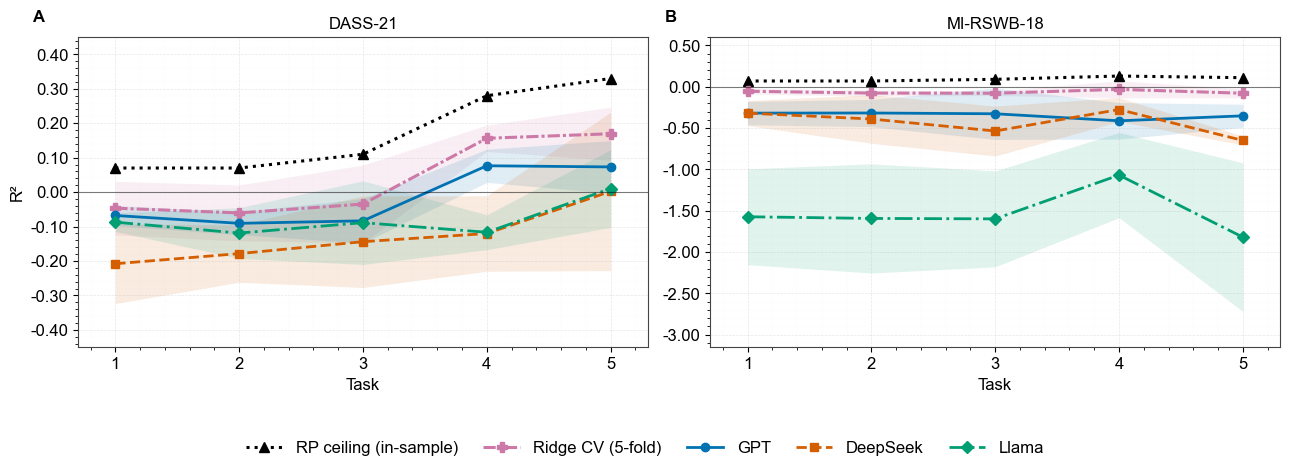

✓ Saved: output/Figure_3.png


In [61]:
# 17. FIGURE 3 — R² across tasks: Ridge CV benchmark vs. LLM synthetic populations
#            Outcomes: DASS-21 total (A) and MI-RSWB-18 total (B), Tasks 1–5
# ============================================================================

from matplotlib.lines import Line2D

# ── Okabe-Ito colorblind-safe palette ────────────────────────────────────────
COLORS = {
    "GPT":       "#0072B2",
    "DeepSeek":  "#D55E00",
    "Llama":     "#009E73",
    "Ridge CV":  "#CC79A7",
    "RP ceiling":"#000000",
}
MARKERS = {
    "GPT": "o", "DeepSeek": "s", "Llama": "D",
    "Ridge CV": "P", "RP ceiling": "^",
}
LINESTYLES = {
    "GPT": "-", "DeepSeek": "--", "Llama": "-.",
    "Ridge CV":   (0, (4, 1, 1, 1)),
    "RP ceiling": ":",
}

# ── In-sample RP R² ceilings per task (computed in Block 9) ──────────────────
# Serve as the upper performance reference for out-of-sample models
RP_CEILING = {
    "DASS-21":    [0.07, 0.07, 0.11, 0.28, 0.33],
    "MI-RSWB-18": [0.07, 0.07, 0.09, 0.13, 0.11],
}

TASK_RANGE   = [1, 2, 3, 4, 5]
SERIES_ORDER = ["RP ceiling", "Ridge CV", "GPT", "DeepSeek", "Llama"]

# Display labels for the shared legend
LEGEND_LABELS = {
    "RP ceiling": "RP ceiling (in-sample)",
    "Ridge CV":   "Ridge CV (5-fold)",
    "GPT":        "GPT",
    "DeepSeek":   "DeepSeek",
    "Llama":      "Llama",
}


# ── Panel rendering function ──────────────────────────────────────────────────
def plot_panel(ax, outcome: str, ylabel: bool = True) -> None:
    """
    Render one R²-vs-task panel for a given outcome.

    Plots the RP ceiling line, Ridge CV benchmark, and three LLM series,
    each with ±1 SD shaded bands (except RP ceiling which has no SD).

    Parameters
    ----------
    ax      : Matplotlib Axes object
    outcome : key in df_rq2 Outcome column ("DASS-21" or "MI-RSWB-18")
    ylabel  : whether to draw the y-axis label
    """
    sub = df_rq2_numeric[df_rq2_numeric["Outcome"] == outcome].copy()
    all_y = []   # collect all y-values to compute panel-specific y-limits

    for key in SERIES_ORDER:
        if key == "RP ceiling":
            y_vals  = RP_CEILING[outcome]
            sd_vals = None                        # no uncertainty for RP ceiling
        elif key == "Ridge CV":
            g       = sub[sub["Predictor"] == "Ridge CV"].sort_values("Step")
            y_vals  = g["R2"].tolist()
            sd_vals = g["R2_sd"].tolist()
        else:
            g       = sub[sub["Predictor"] == key].sort_values("Step")
            y_vals  = g["R2"].tolist()
            sd_vals = g["R2_sd"].tolist()

        all_y.extend([v for v in y_vals if np.isfinite(v)])

        # ── ±1 SD shaded band (only for series with fold-level SD) ───────
        if sd_vals is not None:
            y_arr  = np.array(y_vals,  dtype=float)
            sd_arr = np.array(sd_vals, dtype=float)
            ax.fill_between(
                TASK_RANGE,
                y_arr - sd_arr,
                y_arr + sd_arr,
                color=COLORS[key],
                alpha=0.12,
                linewidth=0,
            )
            all_y.extend((y_arr - sd_arr).tolist())
            all_y.extend((y_arr + sd_arr).tolist())

        # ── Main series line ──────────────────────────────────────────────
        ax.plot(
            TASK_RANGE, y_vals,
            marker=MARKERS[key],
            linestyle=LINESTYLES[key],
            linewidth=2.2 if key in ("RP ceiling", "Ridge CV") else 2.0,
            markersize=7  if key in ("RP ceiling", "Ridge CV") else 6,
            color=COLORS[key],
            label=LEGEND_LABELS[key],
        )

    # ── Per-panel y-limits derived from visible data ──────────────────────────
    y_arr = np.array([v for v in all_y if np.isfinite(v)])
    ymin  = min(float(np.nanmin(y_arr)), 0.0)
    ymax  = max(float(np.nanmax(y_arr)), 0.0)
    span  = (ymax - ymin) if (ymax - ymin) != 0 else 1.0
    ymin  = np.floor((ymin - 0.15 * span) * 20) / 20
    ymax  = np.ceil( (ymax + 0.15 * span) * 20) / 20

    # ── Reference line at R² = 0 ─────────────────────────────────────────────
    ax.axhline(0, color="black", linewidth=0.8, alpha=0.5)

    # ── Axes configuration ────────────────────────────────────────────────────
    ax.set_xlim(0.7, 5.3)
    ax.set_xticks(TASK_RANGE)
    ax.set_xticklabels([str(t) for t in TASK_RANGE], fontsize=12)
    ax.set_xlabel("Task", fontsize=12)
    ax.set_ylim(ymin, ymax)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.2f}"))
    ax.tick_params(axis="y", labelsize=12)

    if ylabel:
        ax.set_ylabel("R²", fontsize=12)

    # ── Grid (major + minor) ──────────────────────────────────────────────────
    ax.grid(True, which="major", linewidth=0.5, alpha=0.3, linestyle="--")
    ax.minorticks_on()
    ax.grid(True, which="minor", linewidth=0.3, alpha=0.15, linestyle=":")

    # ── Visible border box ────────────────────────────────────────────────────
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)
        spine.set_color("#444444")

    ax.set_facecolor("white")


# ── Build figure ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":     "sans-serif",
    "font.sans-serif": ["Arial"],
})

fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(13, 4.5))
fig.patch.set_facecolor("white")

# Panel A — DASS-21
plot_panel(ax_a, "DASS-21",    ylabel=True)
ax_a.set_title("DASS-21",     fontsize=12, pad=6)
ax_a.text(-0.08, 1.04, "A",   transform=ax_a.transAxes,
          fontsize=12, fontweight="bold", va="bottom")

# Panel B — MI-RSWB-18
plot_panel(ax_b, "MI-RSWB-18", ylabel=False)
ax_b.set_title("MI-RSWB-18",  fontsize=12, pad=6)
ax_b.text(-0.08, 1.04, "B",   transform=ax_b.transAxes,
          fontsize=12, fontweight="bold", va="bottom")

# ── Shared horizontal legend below both panels ────────────────────────────────
handles, labels = ax_a.get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center",
    ncol=len(SERIES_ORDER),
    frameon=False,
    fontsize=12,
    bbox_to_anchor=(0.5, -0.06),
    handlelength=2.2,
    columnspacing=1.5,
)

fig.tight_layout(rect=[0, 0.08, 1, 1])   
fig.savefig(
    "output/Figure_3.png",
    dpi=300, bbox_inches="tight",
    facecolor="white"
)
plt.show()
print("✓ Saved: output/Figure_3.png")

### Train/test split on RP data

In [ ]:
# 18. Train/test split on RP data (fixed seed for reproducibility)
# ============================================================================

from sklearn.model_selection import train_test_split

SEED = 42

rp_ids = rp["id"].dropna().astype(int).unique()
train_ids, test_ids = train_test_split(rp_ids, test_size=0.20, random_state=SEED)

rp_train = rp[rp["id"].isin(train_ids)].copy()
rp_test  = rp[rp["id"].isin(test_ids)].copy()

print(f"RP train n = {len(rp_train)}  |  RP test n = {len(rp_test)}")


# ============================================================================
# Shared definitions for Steps 6–8
# ============================================================================

# ── Sociodemographic and clinical predictor columns ───────────────────────────
DEMO_COLS        = ["genero", "edad", "estado_civil", "estudios",
                    "residencia_pais", "nacimiento_pais"]
PAIN_DURATION_COL = "duracion_dolor"
DX_COL            = "causa_dolor"

# ── BPI mean scores used as predictors (aggregated, not individual items) ─────
BPI_MEAN_COLS = ["bpi_interf_mean", "bpi_int_mean"]

# ── Outcomes per step ─────────────────────────────────────────────────────────
# Step 6: both scales generated (BPI provided as input)
# Step 7: only DASS-21 generated (MI-RSWB-18 + BPI provided as input)
# Step 8: only MI-RSWB-18 generated (DASS-21 + BPI provided as input)
OUTCOME_BY_STEP = {
    6: ["dass_total_interp", "mirswb_total"],
    7: ["dass_total_interp"],
    8: ["mirswb_total"],
}

# ── Synthetic dataset registry ────────────────────────────────────────────────
SP_BY_STEP = {
    6: {"GPT": gpt_step6, "DeepSeek": deepseek_step6, "Llama": llama_step6},
    7: {"GPT": gpt_step7, "DeepSeek": deepseek_step7, "Llama": llama_step7},
    8: {"GPT": gpt_step8, "DeepSeek": deepseek_step8, "Llama": llama_step8},
}

MODEL_ORDER = ["GPT", "DeepSeek", "Llama"]


def step_features(step: int) -> list:
    """
    Return predictor columns for Steps 6–8.
    All steps include: SocDemo + pain duration + diagnosis + BPI mean scores.
    Step 7 additionally includes MI-RSWB-18 total (provided as input).
    Step 8 additionally includes DASS-21 total (provided as input).
    """
    base = [c for c in DEMO_COLS if c in rp.columns]
    if PAIN_DURATION_COL in rp.columns:
        base += [PAIN_DURATION_COL]
    if DX_COL in rp.columns:
        base += [DX_COL]
    base += [c for c in BPI_MEAN_COLS if c in rp.columns]   
    if step == 7:
        base += ["mirswb_total"]
    if step == 8:
        base += ["dass_total_interp"]
    return [c for c in base if c in rp.columns]


def make_ridge_pipeline(X_df: pd.DataFrame) -> Pipeline:
    """
    Ridge regression pipeline with median imputation + scaling for numeric
    features and mode imputation + one-hot encoding for categorical features.
    """
    num_cols = [c for c in X_df.columns if pd.api.types.is_numeric_dtype(X_df[c])]
    cat_cols = [c for c in X_df.columns if c not in num_cols]
    pre = ColumnTransformer([
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler",  StandardScaler()),
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore")),
        ]), cat_cols),
    ], remainder="drop")
    return Pipeline([("preprocessor", pre), ("model", Ridge(alpha=1.0))])


# ── Metric helpers ────────────────────────────────────────────────────────────
def eval_metrics(y_true, y_pred) -> dict:
    """Compute R², RMSE, MAE, and ΔMean% for a single prediction vector."""
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    true_mean = np.mean(y_true)
    return {
        "R2":           r2_score(y_true, y_pred),
        "RMSE":         np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE":          mean_absolute_error(y_true, y_pred),
        "DeltaMeanPct": (np.mean(y_pred) - true_mean) / true_mean * 100
                        if true_mean != 0 else np.nan,
    }


def eval_metrics_folds(y_true, y_pred, cv: int = 5) -> dict:
    """
    Estimate fold-level variability of R², RMSE, and MAE on a fixed
    prediction vector by resampling the test set into cv folds.
    No model re-training occurs — folds measure subsampling stability only.
    """
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    if len(y_true) < cv * 2:
        return {k: np.nan for k in
                ["R2", "R2_sd", "RMSE", "RMSE_sd", "MAE", "MAE_sd"]}
    kf = KFold(n_splits=cv, shuffle=True, random_state=SEED)
    r2s, rmses, maes = [], [], []
    for _, te in kf.split(y_true):
        r2s.append(r2_score(y_true[te], y_pred[te]))
        rmses.append(np.sqrt(mean_squared_error(y_true[te], y_pred[te])))
        maes.append(mean_absolute_error(y_true[te], y_pred[te]))
    return {
        "R2":   np.mean(r2s),   "R2_sd":   np.std(r2s,   ddof=1),
        "RMSE": np.mean(rmses), "RMSE_sd": np.std(rmses, ddof=1),
        "MAE":  np.mean(maes),  "MAE_sd":  np.std(maes,  ddof=1),
    }


# ============================================================================
# Train Ridge baseline once; store test-set predictions
# ============================================================================

rp_baseline_preds = {}   

for step in [6, 7, 8]:
    X_cols = step_features(step)
    for outcome in OUTCOME_BY_STEP[step]:
        train_sub = rp_train.dropna(subset=[outcome]).copy()
        test_sub  = rp_test.dropna(subset=[outcome]).copy()

        pipe = make_ridge_pipeline(train_sub[X_cols])
        pipe.fit(train_sub[X_cols], train_sub[outcome].astype(float))

        rp_baseline_preds[(step, outcome)] = pd.DataFrame({
            "id":              test_sub["id"].astype(int).values,
            "y_true":          test_sub[outcome].astype(float).values,
            "y_pred_baseline": pipe.predict(test_sub[X_cols]),
        })

print("✓ Ridge baseline trained and stored for all step/outcome combinations")

### TABLE 6

In [11]:
# 19. Table 6: Wilcoxon signed-rank test + Cliff's delta
# ============================================================================

import re
from scipy.stats import wilcoxon


def cliffs_delta(x, y) -> float:
    """
    Cliff's delta effect size comparing two arrays.
    Positive values indicate x > y on average.
    """
    x, y = np.asarray(x), np.asarray(y)
    gt = sum(np.sum(xi > y) for xi in x)
    lt = sum(np.sum(xi < y) for xi in x)
    return (gt - lt) / (len(x) * len(y))


paired_rows = []

for step in [6, 7, 8]:
    for outcome in OUTCOME_BY_STEP[step]:
        base_df = rp_baseline_preds[(step, outcome)]

        for model_name in MODEL_ORDER:
            sp_df  = SP_BY_STEP[step][model_name]
            llm_df = (sp_df[["id", outcome]]
                      .copy()
                      .assign(id=lambda d: d["id"].astype(int))
                      .rename(columns={outcome: "y_pred_llm"}))

            merged = base_df.merge(llm_df, on="id", how="inner").dropna()
            if len(merged) < 10:
                continue

            y_true = merged["y_true"].to_numpy(float)
            yb     = merged["y_pred_baseline"].to_numpy(float)
            yl     = merged["y_pred_llm"].to_numpy(float)

            ae_b = np.abs(y_true - yb)
            ae_l = np.abs(y_true - yl)
            d_ae = ae_l - ae_b   # positive → LLM error larger than baseline

            w_stat, p_val = wilcoxon(
                d_ae, zero_method="wilcox", alternative="two-sided"
            )

            paired_rows.append({
                "Step":                            step,
                "Outcome":                         outcome,
                "Model":                           model_name,
                "n_test":                          len(merged),
                "median_AE_baseline":              float(np.median(ae_b)),
                "median_AE_llm":                   float(np.median(ae_l)),
                "median_delta_AE":                 float(np.median(d_ae)),
                "mean_delta_AE":                   float(np.mean(d_ae)),
                "pct_llm_worse":                   float(np.mean(d_ae > 0) * 100),
                "pct_llm_better":                  float(np.mean(d_ae < 0) * 100),
                "wilcoxon_W":                      float(w_stat),
                "wilcoxon_p":                      float(p_val),
                "cliffs_delta_AE_llm_vs_baseline": float(cliffs_delta(ae_l, ae_b)),
            })

outcome_order = ["dass_total_interp", "mirswb_total"]
df_paired = (pd.DataFrame(paired_rows)
               .assign(
                   Outcome=lambda d: pd.Categorical(
                       d["Outcome"], categories=outcome_order, ordered=True),
                   Model=lambda d: pd.Categorical(
                       d["Model"], categories=MODEL_ORDER, ordered=True),
               )
               .sort_values(["Outcome", "Step", "Model"])
               .reset_index(drop=True))

display(df_paired.round(4))
print(f"\n✓ Paired comparisons: {df_paired.shape[0]} rows × {df_paired.shape[1]} cols")


# ── Table 6 formatted display ─────────────────────────────────────────────────
def fmt_p(p: float) -> str:
    if p < 0.001:
        return "<.001"
    s = f"{p:.3f}"
    return s.lstrip("0") if s.startswith("0") else s


def fmt_delta(d: float) -> str:
    s = re.sub(r"([+-])0\.", r"\1.", f"{d:+.1f}")
    return s.replace("+", "").replace("-", "−")


t6_rows = []
for (outcome, step), grp in df_paired.groupby(["Outcome", "Step"], sort=True):
    idx = {r["Model"]: r for _, r in grp.iterrows()}
    baseline_mae = idx[MODEL_ORDER[0]]["median_AE_baseline"]
    t6_rows.append({
        "Task":                        step,
        "Outcome":                     outcome,
        "Baseline MedAE":              f"{baseline_mae:.1f}",
        "LLM MedAE (GPT/DS/Llama)":   "/".join(
            f"{idx[m]['median_AE_llm']:.1f}"  for m in MODEL_ORDER),
        "% LLM Worse (GPT/DS/Llama)": "/".join(
            f"{idx[m]['pct_llm_worse']:.1f}"  for m in MODEL_ORDER),
        "P value (GPT/DS/Llama)":      "/".join(
            fmt_p(idx[m]["wilcoxon_p"])        for m in MODEL_ORDER),
        "Cliff's δ (GPT/DS/Llama)":   "/".join(
            fmt_delta(idx[m]["cliffs_delta_AE_llm_vs_baseline"])
            for m in MODEL_ORDER),
    })

df_table6 = pd.DataFrame(t6_rows)
display(df_table6)
print(f"\n✓ Table 6: {df_table6.shape[0]} rows × {df_table6.shape[1]} cols")

NameError: name 'OUTCOME_BY_STEP' is not defined

### FIGURE 4

In [ ]:
# 20. FIGURE 4 — Calibration scatter plots (A–D) + RMSE (E) + Mean bias (F)
#            Steps 6–8, outcomes: DASS-21 total and MI-RSWB-18 total
# ============================================================================

from matplotlib.lines import Line2D
from scipy.stats import pearsonr

# ── Outcome display labels ────────────────────────────────────────────────────
OUTCOME_LABEL = {
    "dass_total_interp": "DASS-21 total",
    "mirswb_total":      "MI-RSWB-18 total",
}

# ── Panel subtitle labels ─────────────────────────────────────────────────────
CONFIG_LABEL = {
    "S6 | dass_total_interp": "Task 6 | DASS-21 total",
    "S7 | dass_total_interp": "Task 7 | DASS-21 total",
    "S6 | mirswb_total":      "Task 6 | MI-RSWB-18 total",
    "S8 | mirswb_total":      "Task 8 | MI-RSWB-18 total",
}

# ── Registry definitions (redeclared here for cell independence) ──────────────
OUTCOME_BY_STEP = {
    6: ["dass_total_interp", "mirswb_total"],
    7: ["dass_total_interp"],
    8: ["mirswb_total"],
}

SP_BY_STEP = {
    6: {"GPT": gpt_step6, "DeepSeek": deepseek_step6, "Llama": llama_step6},
    7: {"GPT": gpt_step7, "DeepSeek": deepseek_step7, "Llama": llama_step7},
    8: {"GPT": gpt_step8, "DeepSeek": deepseek_step8, "Llama": llama_step8},
}

MODEL_ORDER = ["GPT", "DeepSeek", "Llama"]


def calibration_fit(y_true, y_pred, alpha=0.05):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    if len(y_true) < 3:
        return {
            "intercept": np.nan,
            "intercept_ci_low": np.nan,
            "intercept_ci_high": np.nan,
            "slope": np.nan,
            "slope_ci_low": np.nan,
            "slope_ci_high": np.nan,
        }

    try:
        res = stats.linregress(y_pred, y_true)
    except ValueError:
        return {
            "intercept": np.nan,
            "intercept_ci_low": np.nan,
            "intercept_ci_high": np.nan,
            "slope": np.nan,
            "slope_ci_low": np.nan,
            "slope_ci_high": np.nan,
        }

    t_crit = stats.t.ppf(1 - alpha / 2, df=len(y_true) - 2)

    slope_ci_low = res.slope - t_crit * res.stderr
    slope_ci_high = res.slope + t_crit * res.stderr

    intercept_stderr = getattr(res, "intercept_stderr", np.nan)
    intercept_ci_low = res.intercept - t_crit * intercept_stderr
    intercept_ci_high = res.intercept + t_crit * intercept_stderr

    return {
        "intercept": res.intercept,
        "intercept_ci_low": intercept_ci_low,
        "intercept_ci_high": intercept_ci_high,
        "slope": res.slope,
        "slope_ci_low": slope_ci_low,
        "slope_ci_high": slope_ci_high,
    }

# ── Calibration and evaluation helper ────────────────────────────────────────
def compute_eval_and_calib(rp_df, sp_df, outcome, id_col="id", min_n=10):
    """
    Merge RP test set with synthetic data on participant ID, then compute
    RMSE, MAE, mean error, and HC3 calibration slope/intercept.
    Returns raw y_true and y_pred arrays alongside summary statistics.
    """
    merged = rp_df[[id_col, outcome]].merge(
        sp_df[[id_col, outcome]],
        on=id_col, how="inner", suffixes=("_rp", "_sp")
    ).dropna()

    _empty = {k: np.nan for k in [
        "n", "rmse", "mae", "mean_error", "y_true_mean", "y_pred_mean",
        "intercept", "intercept_ci_low", "intercept_ci_high",
        "slope", "slope_ci_low", "slope_ci_high",
    ]}
    _empty.update({"n": len(merged),
                   "y_true": np.array([]), "y_pred": np.array([])})
    if len(merged) < min_n:
        return _empty

    y_true = merged[f"{outcome}_rp"].astype(float).to_numpy()
    y_pred = merged[f"{outcome}_sp"].astype(float).to_numpy()
    err    = y_pred - y_true
    cal    = calibration_fit(y_true, y_pred)   # defined in Block C

    return {
        "n":                 int(len(y_true)),
        "rmse":              float(np.sqrt(np.mean(err ** 2))),
        "mae":               float(np.mean(np.abs(err))),
        "mean_error":        float(np.mean(err)),
        "y_true_mean":       float(np.mean(y_true)),
        "y_pred_mean":       float(np.mean(y_pred)),
        "intercept":         float(cal["intercept"]),
        "intercept_ci_low":  float(cal["intercept_ci_low"]),
        "intercept_ci_high": float(cal["intercept_ci_high"]),
        "slope":             float(cal["slope"]),
        "slope_ci_low":      float(cal["slope_ci_low"]),
        "slope_ci_high":     float(cal["slope_ci_high"]),
        "y_true":            y_true,
        "y_pred":            y_pred,
    }


# ── Collect metrics and raw arrays for all step/outcome/model combinations ────
rows = []
raw  = {}   # key: (step, outcome, model) → dict with y_true, y_pred, slope, intercept

for step in [6, 7, 8]:
    for outcome in OUTCOME_BY_STEP[step]:
        for model_name, sp_df in SP_BY_STEP[step].items():
            met = compute_eval_and_calib(rp_test, sp_df, outcome)
            raw[(step, outcome, model_name)] = {
                "y_true":    met["y_true"],
                "y_pred":    met["y_pred"],
                "slope":     met["slope"],
                "intercept": met["intercept"],
            }
            rows.append({
                "Step":       step,
                "Outcome":    outcome,
                "Model":      model_name,
                "n":          met["n"],
                "rmse":       met["rmse"],
                "delta_mean": (met["y_pred_mean"] - met["y_true_mean"])
                               if np.isfinite(met["y_pred_mean"]) else np.nan,
            })

df = pd.DataFrame(rows)
df["Config"] = df.apply(lambda r: f"S{int(r['Step'])} | {r['Outcome']}", axis=1)

# Only include the four panel configurations shown in the figure
config_order = ["S6 | dass_total_interp", "S7 | dass_total_interp",
                "S6 | mirswb_total",      "S8 | mirswb_total"]
df = df[df["Config"].isin(config_order)].copy()
df["Config"] = pd.Categorical(df["Config"], categories=config_order, ordered=True)
df["Model"]  = pd.Categorical(df["Model"],  categories=MODEL_ORDER,  ordered=True)

configs  = df["Config"].cat.categories.tolist()
n_groups = len(configs)
n_models = len(MODEL_ORDER)
base     = np.arange(n_groups)
offsets  = np.linspace(-0.25, 0.25, n_models)

xlabels = [CONFIG_LABEL.get(c, c) for c in configs]


def get_vals(config, model, col):
    """Extract a single scalar value from the summary DataFrame."""
    sub = df[(df["Config"] == config) & (df["Model"] == model)]
    return float(sub.iloc[0][col]) if len(sub) == 1 else np.nan


# ── Figure layout: rows 0–1 = scatter panels (A–D), row 2 = bar panels (E–F) ─
plt.rcParams.update({
    "font.family":     "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
})

fig = plt.figure(figsize=(13, 18))
fig.patch.set_facecolor("white")
gs  = fig.add_gridspec(
    3, 2,
    hspace=0.50, wspace=0.32,
    top=0.96, bottom=0.10,
    left=0.09, right=0.97,
)


def _style_ax(ax):
    """Apply shared axis styling: white background, visible border, light grid."""
    ax.set_facecolor("white")
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)
        spine.set_color("#444444")
    ax.grid(True, linewidth=0.5, alpha=0.3, linestyle="--")


# ── Panels A–D: calibration scatter with HC3 regression line ─────────────────
scatter_specs = [
    ("S6 | dass_total_interp", 6, "dass_total_interp", gs[0, 0], "A"),
    ("S7 | dass_total_interp", 7, "dass_total_interp", gs[0, 1], "B"),
    ("S6 | mirswb_total",      6, "mirswb_total",      gs[1, 0], "C"),
    ("S8 | mirswb_total",      8, "mirswb_total",      gs[1, 1], "D"),
]

for config_key, step, outcome, gs_pos, letter in scatter_specs:
    ax = fig.add_subplot(gs_pos)
    _style_ax(ax)

    annot_lines = []

    for model in MODEL_ORDER:
        d  = raw.get((step, outcome, model), {})
        yt = d.get("y_true", np.array([]))
        yp = d.get("y_pred", np.array([]))
        if len(yt) < 3:
            continue

        # Scatter points
        ax.scatter(yp, yt, color=COLORS[model], marker=MARKERS[model],
           s=45, alpha=0.65, zorder=3, label=model)

        # HC3 calibration regression line
        sl, icp = d.get("slope", np.nan), d.get("intercept", np.nan)
        if np.isfinite(sl) and np.isfinite(icp):
            x_line = np.linspace(yp.min(), yp.max(), 100)
            ax.plot(x_line, icp + sl * x_line,
                    color=COLORS[model], linestyle=LINESTYLES[model],
                    linewidth=1.8, zorder=4)

        # Per-model Pearson r annotation
        r_val, p_val = pearsonr(yp, yt)
        p_str = "<.001" if p_val < 0.001 else f"{p_val:.3f}".lstrip("0")
        annot_lines.append(
            (model, f"r={r_val:+.2f}, r²={r_val**2:.2f}, p{p_str}")
        )

    # Identity line with decoupled x/y axis ranges
    all_x = [v for d in [raw.get((step, outcome, m), {}) for m in MODEL_ORDER]
             for v in d.get("y_pred", np.array([])).tolist()]
    all_y = [v for d in [raw.get((step, outcome, m), {}) for m in MODEL_ORDER]
             for v in d.get("y_true", np.array([])).tolist()]

    if all_x and all_y:
        pad_x = (max(all_x) - min(all_x)) * 0.05
        pad_y = (max(all_y) - min(all_y)) * 0.05
        ax.set_xlim(min(all_x) - pad_x, max(all_x) + pad_x)
        ax.set_ylim(min(all_y) - pad_y, max(all_y) + pad_y)
        lim_diag = [min(min(all_x), min(all_y)) - max(pad_x, pad_y),
                    max(max(all_x), max(all_y)) + max(pad_x, pad_y)]
        ax.plot(lim_diag, lim_diag, color="black", linestyle=":", linewidth=1.2,
                alpha=0.55, zorder=2, label="Identity (slope = 1)")

    # Stacked per-model annotation boxes
    if annot_lines:
        y_pos = 0.98
        for model, txt in annot_lines:
            ax.text(0.04, y_pos, txt,
                    transform=ax.transAxes, fontsize=12,
                    color=COLORS[model], va="top", ha="left",
                    bbox=dict(boxstyle="round,pad=0.15", facecolor="white",
                              edgecolor=COLORS[model], alpha=0.75, linewidth=0.8))
            y_pos -= 0.09

    ax.set_xlabel(f"LLM predicted\n({OUTCOME_LABEL[outcome]})", fontsize=12)
    ax.set_ylabel("RP observed", fontsize=12)
    ax.set_title(CONFIG_LABEL[config_key], fontsize=12, pad=6)
    ax.tick_params(labelsize=12)
    ax.text(-0.12, 1.04, letter, transform=ax.transAxes,
            fontsize=12, fontweight="bold", va="bottom", ha="left")


# ── Panel E: grouped bar chart of RMSE per configuration and model ─────────────
ax_rmse = fig.add_subplot(gs[2, 0])
_style_ax(ax_rmse)
hatch_map = {0: "", 1: "//", 2: "\\\\"}

for j, model in enumerate(MODEL_ORDER):
    xs = base + offsets[j]
    ys = [get_vals(c, model, "rmse") for c in configs]
    ax_rmse.bar(xs, ys, width=0.20,
                color=COLORS[model],
                edgecolor="white", linewidth=1.5,
                hatch=hatch_map[j], label=model)
    # Value labels above each bar
    for x, y in zip(xs, ys):
        if np.isfinite(y):
            ax_rmse.text(x, y + 0.3, f"{y:.1f}",
                         ha="center", va="bottom",
                         fontsize=12, color=COLORS[model])
            
max_y = max(
    get_vals(c, m, "rmse")
    for c in configs for m in MODEL_ORDER
    if np.isfinite(get_vals(c, m, "rmse"))
)
ax_rmse.set_ylim(0, max_y * 1.15)

ax_rmse.set_xticks(base)
ax_rmse.set_xticklabels(xlabels, rotation=20, ha="right", fontsize=12)
ax_rmse.set_ylabel("RMSE", fontsize=12)
ax_rmse.set_title("Out-of-sample RMSE", fontsize=12, pad=6)
ax_rmse.tick_params(axis="y", labelsize=12)
ax_rmse.text(-0.12, 1.04, "E", transform=ax_rmse.transAxes,
             fontsize=12, fontweight="bold", va="bottom", ha="left")


# ── Panel F: connected dot plot of mean bias per configuration and model ───────
ax_dmean = fig.add_subplot(gs[2, 1])
_style_ax(ax_dmean)

for j, model in enumerate(MODEL_ORDER):
    xs = base + offsets[j]
    ys = [get_vals(c, model, "delta_mean") for c in configs]
    ax_dmean.plot(xs, ys,
                  marker=MARKERS[model], color=COLORS[model],
                  linestyle=LINESTYLES[model], linewidth=2, markersize=8,
                  markerfacecolor=COLORS[model],
                  markeredgecolor="white", markeredgewidth=1,
                  label=model)

ax_dmean.axhline(0.0, linewidth=0.8, color="gray", alpha=0.6)
ax_dmean.set_xticks(base)
ax_dmean.set_xticklabels(xlabels, rotation=20, ha="right", fontsize=12)
ax_dmean.set_ylabel("Predicted mean − RP mean", fontsize=12)
ax_dmean.set_title("Mean bias", fontsize=12, pad=6)
ax_dmean.tick_params(axis="y", labelsize=12)
ax_dmean.text(-0.12, 1.04, "F", transform=ax_dmean.transAxes,
              fontsize=12, fontweight="bold", va="bottom", ha="left")


# ── Shared horizontal legend below all panels ─────────────────────────────────
legend_handles = [
    Line2D([0], [0],
           color=COLORS[m], linestyle=LINESTYLES[m], marker=MARKERS[m],
           markersize=7, linewidth=2, label=m)
    for m in MODEL_ORDER
] + [
    Line2D([0], [0], color="black", linestyle=":", linewidth=1.2,
           label="Identity (slope = 1)")
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.02),
    ncol=len(legend_handles),
    frameon=False,
    fontsize=12,
    handlelength=2.2,
    columnspacing=1.5,
)

fig.savefig(
    "output/Figure_4.png",
    dpi=300, bbox_inches="tight",
    facecolor="white"
)
plt.show()
print("✓ Saved: output/Figure_4.png")

NameError: name 'rp_test' is not defined

### SUPPLEMENTARY TABLE S10

In [ ]:
# 21. Supplementary Table S10: LLM evaluation + calibration metrics
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy import stats


# ── Metric helpers ────────────────────────────────────────────────────────────
def eval_metrics(y_true, y_pred) -> dict:
    """Compute R², RMSE, MAE, ΔMean%, and raw means for a prediction vector."""
    y_true    = np.asarray(y_true, dtype=float)
    y_pred    = np.asarray(y_pred, dtype=float)
    true_mean = np.mean(y_true)
    pred_mean = np.mean(y_pred)
    return {
        "R2":           r2_score(y_true, y_pred),
        "RMSE":         np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE":          mean_absolute_error(y_true, y_pred),
        "DeltaMeanPct": (pred_mean - true_mean) / true_mean * 100
                        if true_mean != 0 else np.nan,
        "true_mean":    true_mean,
        "pred_mean":    pred_mean,
    }


def calibration_fit(y_true, y_pred) -> dict:
    """
    Fit OLS regression: RP_true ~ intercept + slope × LLM_pred
    using HC3 heteroscedasticity-consistent standard errors.
    Returns intercept, slope, and their 95% CIs.
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    X      = sm.add_constant(y_pred)
    model  = sm.OLS(y_true, X).fit(cov_type="HC3")
    ci     = model.conf_int()
    int_ci   = tuple(ci.iloc[0].values) if hasattr(ci, "iloc") else tuple(ci[0])
    slope_ci = tuple(ci.iloc[1].values) if hasattr(ci, "iloc") else tuple(ci[1])
    return {
        "intercept":         float(model.params[0]),
        "intercept_ci_low":  float(int_ci[0]),
        "intercept_ci_high": float(int_ci[1]),
        "slope":             float(model.params[1]),
        "slope_ci_low":      float(slope_ci[0]),
        "slope_ci_high":     float(slope_ci[1]),
    }


# ── Shared registries (consistent with Blocks B–C) ───────────────────────────
OUTCOME_BY_STEP = {
    6: ["dass_total_interp", "mirswb_total"],
    7: ["dass_total_interp"],
    8: ["mirswb_total"],
}

SP_BY_STEP = {
    6: {"GPT": gpt_step6, "DeepSeek": deepseek_step6, "Llama": llama_step6},
    7: {"GPT": gpt_step7, "DeepSeek": deepseek_step7, "Llama": llama_step7},
    8: {"GPT": gpt_step8, "DeepSeek": deepseek_step8, "Llama": llama_step8},
}

OUTCOME_LABEL = {
    "dass_total_interp": "DASS-21 total",
    "mirswb_total":      "MI-RSWB-18 total",
}

MODEL_ORDER = ["GPT", "DeepSeek", "Llama"]
MODEL_SHORT = {"GPT": "GPT", "DeepSeek": "DS", "Llama": "Llama"}


# ============================================================================
# PHASE 1 — LLM calibration metrics on held-out RP test set
# ============================================================================
# Uses bpi_interf_mean and bpi_int_mean via step_features() (defined in Block C)

llm_rows = []
for step, outcomes in OUTCOME_BY_STEP.items():
    for outcome in outcomes:
        for mname, spdf in SP_BY_STEP[step].items():
            merged = rp_test[["id", outcome]].merge(
                spdf[["id", outcome]], on="id",
                how="inner", suffixes=("_rp", "_sp")
            ).dropna()
            y_true = merged[f"{outcome}_rp"].astype(float).values
            y_pred = merged[f"{outcome}_sp"].astype(float).values
            err    = y_pred - y_true
            met    = eval_metrics(y_true, y_pred)
            cal    = calibration_fit(y_true, y_pred)
            llm_rows.append({
                "Step":           step,
                "Outcome":        outcome,
                "Model":          mname,
                "n_test":         len(y_true),
                "delta_mean_pct": met["DeltaMeanPct"],
                "mean_error":     float(np.mean(err)),
                "median_error":   float(np.median(err)),
                "iqr_error":      float(np.quantile(err, .75) - np.quantile(err, .25)),
                "r2":             met["R2"],
                "mae":            met["MAE"],
                "rmse":           met["RMSE"],
                "p95_abs_error":  float(np.quantile(np.abs(err), .95)),
                **cal,
            })

df_calib = pd.DataFrame(llm_rows)
print(f"✓ df_calib: {len(df_calib)} rows")


# ============================================================================
# PHASE 2 — RP Ridge baseline calibration metrics on held-out test set
# ============================================================================

rp_pipe_by_step_outcome = {}
for step in [6, 7, 8]:
    X_cols = step_features(step)
    for outcome in OUTCOME_BY_STEP[step]:
        train_sub = rp_train.dropna(subset=[outcome]).copy()
        pipe      = make_ridge_pipeline(train_sub[X_cols])
        pipe.fit(train_sub[X_cols], train_sub[outcome].astype(float))
        rp_pipe_by_step_outcome[(step, outcome)] = pipe

rp_rows = []
for step in [6, 7, 8]:
    X_cols = step_features(step)
    for outcome in OUTCOME_BY_STEP[step]:
        test_sub = rp_test.dropna(subset=[outcome]).copy()
        y_true   = test_sub[outcome].astype(float).values
        y_pred   = rp_pipe_by_step_outcome[(step, outcome)].predict(
                       test_sub[X_cols])
        err      = y_pred - y_true
        cal      = calibration_fit(y_true, y_pred)
        rp_rows.append({
            "Step":          step,
            "Outcome":       outcome,
            "Model":         "RP_baseline_Ridge",
            "n_test":        len(y_true),
            "mean_error":    float(np.mean(err)),
            "median_error":  float(np.median(err)),
            "iqr_error":     float(np.quantile(err, .75) - np.quantile(err, .25)),
            "r2":            float(r2_score(y_true, y_pred)),
            "mae":           float(np.mean(np.abs(err))),
            "rmse":          float(np.sqrt(np.mean(err ** 2))),
            "p95_abs_error": float(np.quantile(np.abs(err), .95)),
            **cal,
        })

df_rp_calib = pd.DataFrame(rp_rows)
print(f"✓ df_rp_calib: {len(df_rp_calib)} rows")

# ============================================================================
# PHASE 3 — Supplementary Table S10: calibration parameters
# ============================================================================

def fmt_slope_ci(row) -> str:
    """Format calibration slope with 95% CI as 'slope (lo to hi)'."""
    return (f"{row['slope']:.2f} "
            f"({row['slope_ci_low']:.2f} to {row['slope_ci_high']:.2f})")


def tri(grp, col, sign=False) -> str:
    """Return 'GPT_val / DS_val / Llama_val' as a slash-separated string."""
    parts = []
    for m in MODEL_ORDER:
        v = grp.loc[m, col]
        parts.append(f"{v:+.1f}" if sign else f"{v:.1f}")
    return "/".join(parts)


rows_s10 = []
for (step, outcome), grp in (
    df_calib
    .sort_values(["Outcome", "Step"])
    .groupby(["Step", "Outcome"], sort=False)
):
    g   = grp.set_index("Model").reindex(MODEL_ORDER)
    row = {
        "Step":                   step,
        "Outcome":                OUTCOME_LABEL.get(outcome, outcome),
        "ΔMean (%) GPT/DS/Llama": tri(g, "delta_mean_pct", sign=True),
        "RMSE GPT/DS/Llama":      tri(g, "rmse"),
        "MAE GPT/DS/Llama":       tri(g, "mae"),
        "R² GPT/DS/Llama":        tri(g, "r2"),
    }
    for m in MODEL_ORDER:
        row[f"Slope (95% CI) {MODEL_SHORT[m]}"] = fmt_slope_ci(g.loc[m])
    rows_s10.append(row)

df_S10 = pd.DataFrame(rows_s10)
display(df_S10)
print(f"\n✓ Supplementary Table S10: {df_S10.shape[0]} rows × {df_S10.shape[1]} cols")

### SUPPLEMENTARY FIGURE 4

In [ ]:
# 23. Supplementary Figure 4
# calibration scatter plots (4 × 3 grid)
#           12 panels: Steps 6–8 × outcomes × models
# ============================================================================

def _style_ax(ax) -> None:
    """Apply shared panel styling: white background, visible border, light grid."""
    ax.set_facecolor("white")
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)
        spine.set_color("#444444")
    ax.grid(True, linewidth=0.5, alpha=0.3, linestyle="--")


def calibration_scatter_on_ax(ax, rp_test_df, sp_df, outcome,
                               step, model_name) -> None:
    """
    Draw a calibration scatter plot on ax:
    x = LLM-generated values, y = RP observed values.
    Includes identity line (dashed) and HC3 calibration fit (colored).
    Annotates with Pearson r, r², p-value, slope, and intercept with 95% CIs.
    """
    merged = rp_test_df[["id", outcome]].merge(
        sp_df[["id", outcome]], on="id",
        how="inner", suffixes=("_rp", "_sp")
    ).dropna()
    y_true = merged[f"{outcome}_rp"].astype(float).values
    y_pred = merged[f"{outcome}_sp"].astype(float).values

    cal    = calibration_fit(y_true, y_pred)
    b0, b1 = cal["intercept"], cal["slope"]
    r, p   = stats.pearsonr(y_pred, y_true)
    p_str  = "< .001" if p < .001 else f"= {p:.3f}"

    # Scatter points
    ax.scatter(y_pred, y_true,
               alpha=0.65, s=22, zorder=3,
               color=COLORS.get(model_name, "#555555"))


    # Decoupled axis ranges
    xs = np.linspace(y_pred.min(), y_pred.max(), 200)   # calibration line spans x only

    # Identity line spans the full diagonal
    diag_min = min(y_pred.min(), y_true.min())
    diag_max = max(y_pred.max(), y_true.max())
    ax.plot([diag_min, diag_max], [diag_min, diag_max],
            lw=1.6, ls="--", color="gray",
            label="Identity (y = x)", zorder=2)

    ax.plot(xs, b0 + b1 * xs,
            lw=1.8, color=COLORS.get(model_name, "tomato"),
            label="Calibration fit (HC3)", zorder=4)

    # Set axes limits independently
    pad_x = (y_pred.max() - y_pred.min()) * 0.05
    pad_y = (y_true.max() - y_true.min()) * 0.05
    ax.set_xlim(y_pred.min() - pad_x, y_pred.max() + pad_x)
    ax.set_ylim(y_true.min() - pad_y, y_true.max() + pad_y)

    # Annotation box with key statistics
    annot = (
        f"r = {r:+.2f},  r² = {r**2:.2f},  p {p_str}\n"
        f"slope = {b1:.2f}  [{cal['slope_ci_low']:.2f}, "
        f"{cal['slope_ci_high']:.2f}]\n"
        f"intercept = {b0:.1f}  [{cal['intercept_ci_low']:.1f}, "
        f"{cal['intercept_ci_high']:.1f}]"
    )
    ax.text(0.05, 0.95, annot,
            transform=ax.transAxes, fontsize=12,
            va="top", ha="left",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                      edgecolor="lightgray", alpha=0.85))

    ax.set_xlabel(
        f"{model_name} generated\n({OUTCOME_LABEL.get(outcome, outcome)})",
        fontsize=12)
    ax.set_ylabel("RP observed", fontsize=12)
    ax.set_title(
        f"Task {step} | {OUTCOME_LABEL.get(outcome, outcome)} | {model_name}",
        fontsize=12, fontweight="bold", pad=5)
    ax.legend(fontsize=12, loc="lower right", framealpha=0.8, frameon=True)


# ── Build ordered list of 12 panels ──────────────────────────────────────────
plot_specs = []
for step in [6, 7, 8]:
    for outcome in OUTCOME_BY_STEP[step]:
        for model_name, sp_df in SP_BY_STEP[step].items():
            plot_specs.append((step, outcome, model_name, sp_df))

assert len(plot_specs) == 12, f"Expected 12 panels, got {len(plot_specs)}"

# ── Figure ────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":     "sans-serif",
    "font.sans-serif": ["Arial"],
})

fig, axes = plt.subplots(4, 3, figsize=(14, 18))
fig.patch.set_facecolor("white")
axes_flat = np.asarray(axes).ravel()

for i, (step, outcome, model_name, sp_df) in enumerate(plot_specs):
    ax = axes_flat[i]
    _style_ax(ax)
    calibration_scatter_on_ax(ax, rp_test, sp_df, outcome, step, model_name)

    # Bold panel letter (A–L)
    ax.text(-0.12, 1.05, chr(65 + i),
            transform=ax.transAxes,
            fontsize=12, fontweight="bold", va="bottom", ha="left")

fig.tight_layout(rect=[0, 0.0, 1, 1])
fig.savefig(
    "output/Supplementary_Figure_4.png",
    dpi=300, bbox_inches="tight",
    facecolor="white"
)
plt.show()
print("✓ Saved: output/Supplementary_Figure_4.png")